# Paper 2 — Bamboo Acoustic Feature Extraction, Robust Version

**Purpose.** This notebook extracts the acoustic features needed for Paper 2 Study Goal 2 from Bamboo Passage recordings. It is intentionally separated from the modeling notebook. Its job is only to:

1. load audio robustly, including mislabeled `.wav` files that are actually EBML/WebM/Matroska-like containers;
2. compute an explicitly documented acoustic feature set by subsystem;
3. support single-recording, random-batch, and full-dataset extraction;
4. save a recording-level acoustic feature table;
5. audit extraction quality with plots, missingness, timing, and error summaries.

**Design principle.** The uploaded legacy `all_bamboo_features_code.py` is treated as the feature-name and subsystem reference, but this notebook avoids importing it directly because that script mixes file decoding, feature computation, printing, and several slow/fragile operations. This version reimplements the feature groups with bounded windows, robust decoding, explicit failure handling, and progress bars.

## Cell 1 — Imports and display settings

This cell imports only the packages required for robust extraction. The notebook avoids `scipy.io.wavfile.read()` as the primary loader because some files use a `.wav` suffix but are not true RIFF/WAV files. `librosa.load()` is used as the primary decoder because it successfully handles the EBML/container cases seen in this dataset.

In [1]:
from pathlib import Path
import os
import sys
import json
import time
import math
import hashlib
import warnings
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from IPython.display import display

import scipy.signal as sps
from scipy.signal import butter, filtfilt, lfilter, find_peaks, welch
from scipy.fft import rfft, rfftfreq, irfft

import librosa
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 250)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print("Imports complete.")
print("librosa:", librosa.__version__)

Imports complete.
librosa: 0.11.0


## Cell 2 — Project paths and run controls

Edit only this cell when moving between machines. The root path is your current Windows Paper 2 root. The notebook reads the Paper 1 recording-level Q dataset only to get recording IDs, diagnosis labels, and audio paths. It writes the new acoustic feature table into `paper2/data/interim/acoustic_features`.

Extraction modes:

- `single`: one recording only, for debugging;
- `batch`: random subset, for checking stability before full extraction;
- `full`: all available recordings.

The default is `single` to prevent accidental long runs.

In [46]:
# ------------------------------------------------------------
# Canonical Windows root
# ------------------------------------------------------------

PAPER2_ROOT = Path(
    r"C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper2"
)

PROJECT_ROOT = PAPER2_ROOT.parent
PAPER1_ROOT = PROJECT_ROOT / "paper1"
PAPER1_PIPELINE_DATA = PAPER1_ROOT / "paper1_pipeline" / "data"
PAPER1_PROCESSED_DATA = PAPER1_PIPELINE_DATA / "processed"

RECORDING_Q_CSV = PAPER1_PROCESSED_DATA / "analysis_ready_recording_level_q_dataset.csv"

# The audio files may live under Paper 1. Add more roots here if needed.
AUDIO_SEARCH_ROOTS = [
    PAPER1_ROOT,
    PROJECT_ROOT,
]

# ------------------------------------------------------------
# Output locations
# ------------------------------------------------------------

ACOUSTIC_DIR = PAPER2_ROOT / "data" / "interim" / "acoustic_features"
RESULTS_DIR = PAPER2_ROOT / "results" / "acoustic_feature_extraction"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
LOG_DIR = RESULTS_DIR / "logs"

for d in [ACOUSTIC_DIR, RESULTS_DIR, TABLES_DIR, FIGURES_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

ACOUSTIC_FEATURE_FILE = ACOUSTIC_DIR / "bamboo_acoustic_features_recording_level.csv"
ACOUSTIC_ERROR_FILE = LOG_DIR / "bamboo_acoustic_feature_errors.csv"
AUDIO_INDEX_FILE = LOG_DIR / "bamboo_audio_path_resolution.csv"
RUN_CONFIG_FILE = LOG_DIR / "bamboo_acoustic_feature_extraction_run_config.json"

# ------------------------------------------------------------
# Run mode
# ------------------------------------------------------------
# Choose one: "single", "batch", "full"
EXTRACTION_MODE = "single"
#EXTRACTION_MODE = "batch"
EXTRACTION_MODE = "full"

SINGLE_INDEX = 0
RANDOM_BATCH_N = 25
OVERWRITE_EXISTING_FEATURE_FILE = True

# Checkpointing matters for full extraction.
CHECKPOINT_EVERY_N = 25

# Audio standardization.
TARGET_SR = 16000
BAMBOO_WORD_COUNT = 99

# ------------------------------------------------------------
# Subsystem controls
# ------------------------------------------------------------
# Keep all True for full intended extraction. If debugging speed,
# turn off one subsystem at a time.
EXTRACT_TIMING = True
EXTRACT_FORMANTS = True
EXTRACT_F0 = True
EXTRACT_CPP = True
EXTRACT_EMS = True
EXTRACT_HARMONIC_SPECTRAL = True

# Bounded-window controls for speed and interpretability.
MAX_FORMANT_FRAMES = 80
MAX_CPP_FRAMES = 300
FORMANT_FRAME_SEC = 0.040
FORMANT_HOP_SEC = 0.040
F0_FRAME_SEC = 0.040
F0_HOP_SEC = 0.020
CPP_FRAME_SEC = 0.040
CPP_HOP_SEC = 0.020

# Save diagnostic plots for single/batch/full outputs.
SAVE_PLOTS = True

run_config = {
    "timestamp": datetime.now().isoformat(),
    "paper2_root": str(PAPER2_ROOT),
    "recording_q_csv": str(RECORDING_Q_CSV),
    "acoustic_feature_file": str(ACOUSTIC_FEATURE_FILE),
    "extraction_mode": EXTRACTION_MODE,
    "target_sr": TARGET_SR,
    "bamboo_word_count": BAMBOO_WORD_COUNT,
    "subsystems": {
        "timing": EXTRACT_TIMING,
        "formants": EXTRACT_FORMANTS,
        "f0": EXTRACT_F0,
        "cpp": EXTRACT_CPP,
        "ems": EXTRACT_EMS,
        "harmonic_spectral": EXTRACT_HARMONIC_SPECTRAL,
    },
}

with open(RUN_CONFIG_FILE, "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=2)

print("Paper 2 root:", PAPER2_ROOT)
print("Recording Q CSV:", RECORDING_Q_CSV)
print("Acoustic output:", ACOUSTIC_FEATURE_FILE)
print("Mode:", EXTRACTION_MODE)
print("Target sample rate:", TARGET_SR)
print("\nExistence checks:")
print("PAPER2_ROOT:", PAPER2_ROOT.exists())
print("RECORDING_Q_CSV:", RECORDING_Q_CSV.exists())

if not PAPER2_ROOT.exists():
    raise FileNotFoundError(PAPER2_ROOT)
if not RECORDING_Q_CSV.exists():
    raise FileNotFoundError(RECORDING_Q_CSV)

Paper 2 root: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper2
Recording Q CSV: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\paper1_pipeline\data\processed\analysis_ready_recording_level_q_dataset.csv
Acoustic output: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper2\data\interim\acoustic_features\bamboo_acoustic_features_recording_level.csv
Mode: full
Target sample rate: 16000

Existence checks:
PAPER2_ROOT: True
RECORDING_Q_CSV: True


## Cell 3 — Feature registry

This registry defines the feature names, subsystems, and interpretations used by this notebook. It mirrors the legacy feature groups:

- speech/pause timing;
- formant central tendency and bandwidth;
- formant dynamics;
- F0/prosody;
- cepstral peak prominence and coordination complexity;
- envelope modulation spectrum;
- harmonic/spectral/nasality-style measures.

The registry is saved as a CSV so the modeling notebook can use it later.

In [47]:
FEATURE_REGISTRY_ROWS = []

def add_feature(name, subsystem, meaning, unit="", computation_note=""):
    FEATURE_REGISTRY_ROWS.append({
        "feature": name,
        "subsystem": subsystem,
        "meaning": meaning,
        "unit": unit,
        "computation_note": computation_note,
    })

# Speech/pause timing features.
for name, meaning, unit in [
    ("speech_rate", "Bamboo words per minute over effective task duration", "words/min"),
    ("total_dur", "Effective analyzed duration after trimming leading/trailing silence", "s"),
    ("speech_dur", "Total non-silent phrase duration inside effective task interval", "s"),
    ("percent_pause", "Internal pause duration divided by effective duration", "proportion"),
    ("num_pause", "Number of internal pauses meeting minimum pause duration", "count"),
    ("mean_pause_dur", "Mean internal pause duration", "s"),
    ("mean_phrase_dur", "Mean speech phrase duration between pauses", "s"),
    ("cv_pause_dur", "Coefficient of variation of internal pause durations", "unitless"),
    ("cv_phrase_dur", "Coefficient of variation of speech phrase durations", "unitless"),
    ("total_pause_dur", "Total internal pause duration", "s"),
]:
    add_feature(name, "speech_pause_timing", meaning, unit, "RMS-based adaptive silence detection.")

# Formants and bandwidths.
for i in range(1, 6):
    add_feature(f"f{i}", "formant_frequency", f"Median F{i} across selected high-energy short frames", "Hz", "LPC on bounded high-energy 40 ms windows.")
for i in range(1, 6):
    add_feature(f"f{i}_bw", "formant_bandwidth", f"Median F{i} bandwidth across selected high-energy short frames", "Hz", "LPC root bandwidth.")

# Formant dynamics.
for i in range(1, 4):
    for suffix, meaning in [
        ("d_dx_median", "Median first derivative over selected formant track"),
        ("d_dx_prc_5", "5th percentile of first derivative over selected formant track"),
        ("d_dx_prc_95", "95th percentile of first derivative over selected formant track"),
        ("d_dx_prc_5_95", "95th minus 5th percentile derivative range"),
    ]:
        add_feature(f"f{i}_{suffix}", "formant_dynamics", f"F{i} {meaning}", "Hz/s", "Gradient over selected high-energy frame times.")
for i in range(1, 4):
    add_feature(f"f{i}_range", "formant_range", f"Robust F{i} range: 95th minus 5th percentile", "Hz", "Computed over selected high-energy frames.")

# F0.
add_feature("f0_mean", "f0_prosody", "Mean voiced fundamental frequency", "Hz", "librosa.yin, valid frames only.")
add_feature("f0_std", "f0_prosody", "Standard deviation of voiced fundamental frequency", "Hz", "librosa.yin, valid frames only.")

# CPP and coordination complexity.
add_feature("CPP_mean", "cepstral_voice_quality", "Mean cepstral peak prominence proxy", "dB-like", "Cepstral peak prominence over selected high-energy frames.")
add_feature("CPP_F1_comp", "coordination_complexity", "Complexity index for CPP and F1 tracks", "index", "Number of PCA components explaining 95% variance.")
add_feature("CPP_F2_comp", "coordination_complexity", "Complexity index for CPP and F2 tracks", "index", "Number of PCA components explaining 95% variance.")
add_feature("F1_F2_comp", "coordination_complexity", "Complexity index for F1 and F2 tracks", "index", "Number of PCA components explaining 95% variance.")

# EMS.
for name, meaning, unit in [
    ("intensity_CV", "Coefficient of variation of RMS intensity", "unitless"),
    ("fft_peaks1", "Strongest envelope modulation frequency", "Hz"),
    ("fft_peaks2", "Second strongest envelope modulation frequency", "Hz"),
    ("fft_ampli1", "Amplitude at strongest envelope modulation peak", "a.u."),
    ("fft_ampli2", "Amplitude at second envelope modulation peak", "a.u."),
    ("nrj_below_boundary", "Envelope modulation energy below 4 Hz", "proportion"),
    ("nrj_above_boundary", "Envelope modulation energy from 4 to 10 Hz", "proportion"),
    ("nrj_3_6", "Envelope modulation energy from 3 to 6 Hz", "proportion"),
    ("ratio_below_above", "Energy below 4 Hz divided by energy 4 to 10 Hz", "ratio"),
]:
    add_feature(name, "envelope_modulation_spectrum", meaning, unit, "Envelope from 300-1000 Hz band, low-pass, downsampled to 100 Hz.")

# Harmonic/spectral/nasality-style features.
for name, meaning, unit in [
    ("A1P0", "Amplitude difference between F1-region peak and low-frequency nasal-region peak", "dB"),
    ("A1P0comp", "Binary/continuous compression proxy for A1-P0 relation", "dB"),
    ("A1P1", "Amplitude difference between F1-region peak and ~1 kHz nasal-region peak", "dB"),
    ("A1P1comp", "Binary/continuous compression proxy for A1-P1 relation", "dB"),
    ("A3P0", "Amplitude difference between F3-region peak and low-frequency nasal-region peak", "dB"),
    ("F1freq", "Frequency of F1-region spectral peak", "Hz"),
    ("F1amp", "Amplitude of F1-region spectral peak", "dB"),
    ("F1width", "Approximate F1 bandwidth from LPC summary", "Hz"),
    ("F2freq", "Frequency of F2-region spectral peak", "Hz"),
    ("F2amp", "Amplitude of F2-region spectral peak", "dB"),
    ("F2width", "Approximate F2 bandwidth from LPC summary", "Hz"),
    ("F3freq", "Frequency of F3-region spectral peak", "Hz"),
    ("F3amp", "Amplitude of F3-region spectral peak", "dB"),
    ("F3width", "Approximate F3 bandwidth from LPC summary", "Hz"),
    ("H1freq", "Estimated first harmonic frequency", "Hz"),
    ("H1amp", "Amplitude around first harmonic", "dB"),
    ("H2freq", "Estimated second harmonic frequency", "Hz"),
    ("H2amp", "Amplitude around second harmonic", "dB"),
    ("P0freq", "Low-frequency nasal-region peak frequency", "Hz"),
    ("P0amp", "Low-frequency nasal-region peak amplitude", "dB"),
    ("P0prom", "P0 prominence over local spectral median", "dB"),
    ("P1amp", "~1 kHz nasal-region peak amplitude", "dB"),
    ("RMSamp", "Global RMS amplitude", "linear"),
]:
    add_feature(name, "harmonic_spectral_nasality_proxy", meaning, unit, "Welch spectrum plus F0/formant summaries.")

FEATURE_REGISTRY = pd.DataFrame(FEATURE_REGISTRY_ROWS)
ALL_FEATURE_NAMES = FEATURE_REGISTRY["feature"].tolist()

FEATURE_REGISTRY_FILE = TABLES_DIR / "bamboo_acoustic_feature_registry.csv"
FEATURE_REGISTRY.to_csv(FEATURE_REGISTRY_FILE, index=False)

print("Number of registered features:", len(ALL_FEATURE_NAMES))
print("Registry saved:", FEATURE_REGISTRY_FILE)
display(FEATURE_REGISTRY.groupby("subsystem").size().rename("n_features").to_frame())
display(FEATURE_REGISTRY.head(20))

Number of registered features: 73
Registry saved: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper2\results\acoustic_feature_extraction\tables\bamboo_acoustic_feature_registry.csv


,n_features
subsystem,
cepstral_voice_quality,1
coordination_complexity,3
envelope_modulation_spectrum,9
f0_prosody,2
formant_bandwidth,5
formant_dynamics,12
formant_frequency,5
formant_range,3
harmonic_spectral_nasality_proxy,23


,feature,subsystem,meaning,unit,computation_note
0,speech_rate,speech_pause_timing,Bamboo words per minute over effective task duration,words/min,RMS-based adaptive silence detection.
1,total_dur,speech_pause_timing,Effective analyzed duration after trimming leading/trailing silence,s,RMS-based adaptive silence detection.
2,speech_dur,speech_pause_timing,Total non-silent phrase duration inside effective task interval,s,RMS-based adaptive silence detection.
3,percent_pause,speech_pause_timing,Internal pause duration divided by effective duration,proportion,RMS-based adaptive silence detection.
4,num_pause,speech_pause_timing,Number of internal pauses meeting minimum pause duration,count,RMS-based adaptive silence detection.
5,mean_pause_dur,speech_pause_timing,Mean internal pause duration,s,RMS-based adaptive silence detection.
6,mean_phrase_dur,speech_pause_timing,Mean speech phrase duration between pauses,s,RMS-based adaptive silence detection.
7,cv_pause_dur,speech_pause_timing,Coefficient of variation of internal pause durations,unitless,RMS-based adaptive silence detection.
8,cv_phrase_dur,speech_pause_timing,Coefficient of variation of speech phrase durations,unitless,RMS-based adaptive silence detection.
9,total_pause_dur,speech_pause_timing,Total internal pause duration,s,RMS-based adaptive silence detection.


## Cell 4 — Load recording metadata and resolve audio paths

The Paper 1 analysis-ready Q file already contains `file_name`, `ID_norm`, diagnosis labels, and usually `file_path`. We use it as the recording index. Path resolution is explicit and audited because later modeling must know which recordings actually had extractable audio.

This cell does not decode audio yet. It only resolves paths and checks that files exist.

In [48]:
rec_df = pd.read_csv(RECORDING_Q_CSV)

if "diagnosis_group" not in rec_df.columns and "Diagnosis" in rec_df.columns:
    rec_df["diagnosis_group"] = rec_df["Diagnosis"]

if "Recording date" in rec_df.columns:
    rec_df["Recording date"] = pd.to_datetime(rec_df["Recording date"], errors="coerce")

required_cols = ["file_name", "ID_norm", "diagnosis_group"]
missing = [c for c in required_cols if c not in rec_df.columns]
if missing:
    raise KeyError(f"Missing required columns in recording Q CSV: {missing}")

def resolve_candidate_path(row):
    # First trust file_path when it exists.
    if "file_path" in row.index and pd.notna(row["file_path"]):
        p = Path(str(row["file_path"]))
        if p.exists():
            return p

    # Otherwise search under known roots by filename.
    fname = str(row["file_name"])
    for root in AUDIO_SEARCH_ROOTS:
        if root.exists():
            hits = list(root.rglob(fname))
            if hits:
                return hits[0]

    return None

audio_index_df = rec_df[[
    c for c in ["file_name", "file_path", "ID_norm", "diagnosis_group", "Diagnosis", "Recording date", "severity_bin"]
    if c in rec_df.columns
]].copy()

resolved_paths = []
for _, row in tqdm(audio_index_df.iterrows(), total=len(audio_index_df), desc="Resolving audio paths"):
    p = resolve_candidate_path(row)
    resolved_paths.append(str(p) if p is not None else None)

audio_index_df["audio_path"] = resolved_paths
audio_index_df["audio_exists"] = audio_index_df["audio_path"].map(lambda x: Path(str(x)).exists() if pd.notna(x) else False)

audio_index_df.to_csv(AUDIO_INDEX_FILE, index=False)

summary = pd.DataFrame({
    "metric": ["n_recordings", "n_audio_found", "n_audio_missing", "fraction_found"],
    "value": [
        len(audio_index_df),
        int(audio_index_df["audio_exists"].sum()),
        int((~audio_index_df["audio_exists"]).sum()),
        float(audio_index_df["audio_exists"].mean()),
    ]
})
display(summary)
display(audio_index_df.head(5))

available_audio_df = audio_index_df.loc[audio_index_df["audio_exists"]].copy().reset_index(drop=True)
if len(available_audio_df) == 0:
    raise RuntimeError("No audio files were found. Fix AUDIO_SEARCH_ROOTS or file_path resolution.")

Resolving audio paths:   0%|          | 0/556 [00:00<?, ?it/s]

,metric,value
0,n_recordings,556.0
1,n_audio_found,556.0
2,n_audio_missing,0.0
3,fraction_found,1.0


,file_name,file_path,ID_norm,diagnosis_group,Diagnosis,Recording date,severity_bin,audio_path,audio_exists
0,CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000001\272\1\20220518\CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav,CAPT0000001,ALS,ALS,2022-05-18,Mild (9–10),C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000001\272\1\20220518\CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav,True
1,CAPT0000002_272_2_20221114_240_PSG_BAMBOO.wav,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000002\272\2\20221114\CAPT0000002_272_2_20221114_240_PSG_BAMBOO.wav,CAPT0000002,ALS,ALS,2022-11-14,Normal (11–12),C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000002\272\2\20221114\CAPT0000002_272_2_20221114_240_PSG_BAMBOO.wav,True
2,CAPT0000003_272_1_20220623_240_PSG_BAMBOO.wav,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000003\272\1\20220623\CAPT0000003_272_1_20220623_240_PSG_BAMBOO.wav,CAPT0000003,Control,Control,2022-06-23,NaN,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000003\272\1\20220623\CAPT0000003_272_1_20220623_240_PSG_BAMBOO.wav,True
3,CAPT0000003_272_2_20230315_240_PSG_BAMBOO.wav,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000003\272\2\20230315\CAPT0000003_272_2_20230315_240_PSG_BAMBOO.wav,CAPT0000003,Control,Control,2023-03-15,NaN,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000003\272\2\20230315\CAPT0000003_272_2_20230315_240_PSG_BAMBOO.wav,True
4,CAPT0000004_272_2_20221208_240_PSG_BAMBOO.wav,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000004\272\2\20221208\CAPT0000004_272_2_20221208_240_PSG_BAMBOO.wav,CAPT0000004,ALS,ALS,2022-12-08,Normal (11–12),C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000004\272\2\20221208\CAPT0000004_272_2_20221208_240_PSG_BAMBOO.wav,True


## Cell 5 — Container/header diagnostics

Some files have a `.wav` suffix but are not true RIFF/WAV files. This cell reads the first bytes of each file to identify the actual container class. A true WAV starts with `RIFF`, while EBML/WebM/Matroska-like containers start with bytes `1A 45 DF A3`. This is why `scipy.wavfile.read()` can fail even when the filename ends in `.wav`.

The extraction code below uses `librosa.load()` and resamples to 16 kHz, so it can handle the observed container mismatch.

Reading file headers:   0%|          | 0/556 [00:00<?, ?it/s]

,n
container_guess,
ebml_webm_matroska_like,329
riff_wav,219
other_non_riff,8


,file_name,ID_norm,audio_path,header_bytes,container_guess
0,CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav,CAPT0000001,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000001\272\1\20220518\CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav,b'\x1aE\xdf\xa3',ebml_webm_matroska_like
1,CAPT0000002_272_2_20221114_240_PSG_BAMBOO.wav,CAPT0000002,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000002\272\2\20221114\CAPT0000002_272_2_20221114_240_PSG_BAMBOO.wav,b'\x1aE\xdf\xa3',ebml_webm_matroska_like
2,CAPT0000003_272_1_20220623_240_PSG_BAMBOO.wav,CAPT0000003,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000003\272\1\20220623\CAPT0000003_272_1_20220623_240_PSG_BAMBOO.wav,b'\x1aE\xdf\xa3',ebml_webm_matroska_like
3,CAPT0000003_272_2_20230315_240_PSG_BAMBOO.wav,CAPT0000003,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000003\272\2\20230315\CAPT0000003_272_2_20230315_240_PSG_BAMBOO.wav,b'\x1aE\xdf\xa3',ebml_webm_matroska_like
4,CAPT0000004_272_2_20221208_240_PSG_BAMBOO.wav,CAPT0000004,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000004\272\2\20221208\CAPT0000004_272_2_20221208_240_PSG_BAMBOO.wav,b'\x1aE\xdf\xa3',ebml_webm_matroska_like


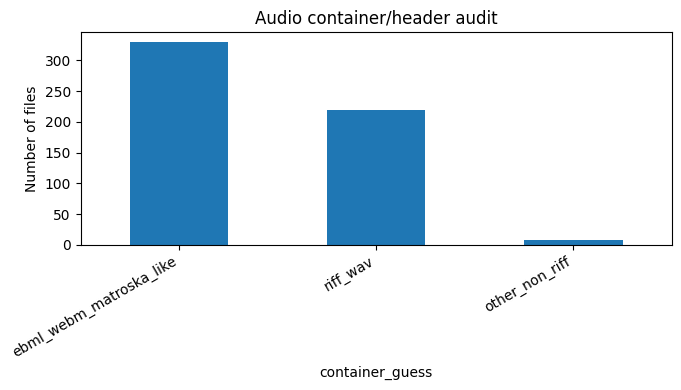

In [49]:
def read_header_bytes(path, n=4):
    try:
        with open(path, "rb") as f:
            return f.read(n)
    except Exception:
        return None

def interpret_header(header):
    if header == b"RIFF":
        return "riff_wav"
    if header == bytes([0x1A, 0x45, 0xDF, 0xA3]):
        return "ebml_webm_matroska_like"
    if header is None:
        return "unreadable"
    return "other_non_riff"

header_rows = []
for _, row in tqdm(available_audio_df.iterrows(), total=len(available_audio_df), desc="Reading file headers"):
    header = read_header_bytes(row["audio_path"])
    header_rows.append({
        "file_name": row["file_name"],
        "ID_norm": row["ID_norm"],
        "audio_path": row["audio_path"],
        "header_bytes": repr(header),
        "container_guess": interpret_header(header),
    })

container_df = pd.DataFrame(header_rows)
container_df.to_csv(TABLES_DIR / "bamboo_audio_container_header_audit.csv", index=False)

display(container_df["container_guess"].value_counts(dropna=False).rename("n").to_frame())
display(container_df.head())

if SAVE_PLOTS:
    plt.figure(figsize=(7, 4))
    container_df["container_guess"].value_counts().plot(kind="bar")
    plt.ylabel("Number of files")
    plt.title("Audio container/header audit")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "audio_container_header_audit.png", dpi=300, bbox_inches="tight")
    plt.show()

## Cell 6 — Robust audio loader

All feature functions receive a decoded mono waveform and sample rate. This design prevents individual feature functions from trying to open the file differently. That is critical here because the file extension is not a reliable indicator of container type.

The loader returns:
- waveform `y`;
- sample rate `sr`;
- loader label;
- duration.

In [50]:
from pathlib import Path
import numpy as np
import librosa
import scipy.signal as sps

def load_audio_mono(audio_path, target_sr=16000, return_loader=True):
    """
    Robust loader for Bamboo files.

    Important:
    Some Bamboo files have .wav extensions but are actually EBML/WebM/Matroska-like
    containers. scipy.io.wavfile and soundfile may fail. librosa can decode them,
    but librosa's default resampling may require optional dependencies such as
    resampy. To avoid that dependency, this function loads at the native sample
    rate first, then resamples with scipy.signal.resample_poly.
    """
    audio_path = str(audio_path)

    # Load at native sampling rate. This avoids librosa's internal resampler.
    y, native_sr = librosa.load(
        audio_path,
        sr=None,
        mono=True,
    )

    y = np.asarray(y, dtype=np.float32)

    if y.size == 0:
        raise ValueError("Loaded audio is empty.")

    if not np.isfinite(y).all():
        y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)

    loader_used = "librosa_native"

    if target_sr is not None and int(native_sr) != int(target_sr):
        # Polyphase resampling is fast and avoids resampy.
        gcd = np.gcd(int(native_sr), int(target_sr))
        up = int(target_sr // gcd)
        down = int(native_sr // gcd)

        y = sps.resample_poly(y, up=up, down=down).astype(np.float32)
        sr = int(target_sr)
        loader_used = "librosa_native_scipy_resample_poly"
    else:
        sr = int(native_sr)

    # Safety normalization: do not force peak normalization; preserve relative amplitude.
    y = np.asarray(y, dtype=np.float32)

    if return_loader:
        return y, sr, loader_used
    return y, sr

# Test loader on one file.
test_row = available_audio_df.iloc[SINGLE_INDEX]
test_path = Path(test_row["audio_path"])

header = read_header_bytes(test_path)
print("Test file:", test_row["file_name"])
print("Path:", test_path)
print("Header:", repr(header), interpret_header(header))
print("Exists:", test_path.exists())
print("Size MB:", test_path.stat().st_size / 1e6)

t0 = time.time()
y_test, sr_test, loader_test = load_audio_mono(test_path, target_sr=TARGET_SR, return_loader=True)
print("Loaded with:", loader_test)
print("Sample rate:", sr_test)
print("Shape:", y_test.shape)
print("Duration sec:", len(y_test) / sr_test)
print("Min/max:", float(np.min(y_test)), float(np.max(y_test)))
print("Load time sec:", time.time() - t0)

Test file: CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav
Path: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000001\272\1\20220518\CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav
Header: b'\x1aE\xdf\xa3' ebml_webm_matroska_like
Exists: True
Size MB: 1.047724
Loaded with: librosa_native_scipy_resample_poly
Sample rate: 16000
Shape: (1034880,)
Duration sec: 64.68
Min/max: -0.7529411911964417 0.6534727811813354
Load time sec: 0.16823720932006836


## Cell 7 — Low-level signal utilities

These utilities are deliberately small, vectorized, and reusable. They avoid printing inside feature functions so full extraction remains readable and fast.

In [51]:
EPS = 1e-12

def safe_float(x):
    try:
        if x is None:
            return np.nan
        x = float(x)
        return x if np.isfinite(x) else np.nan
    except Exception:
        return np.nan

def naniqr(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    return float(np.nanquantile(x, 0.75) - np.nanquantile(x, 0.25))

def coefficient_of_variation(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return np.nan
    mu = np.mean(x)
    if np.isclose(mu, 0):
        return np.nan
    return float(np.std(x) / mu)

def frame_signal(y, sr, frame_sec, hop_sec):
    frame_length = max(1, int(round(frame_sec * sr)))
    hop_length = max(1, int(round(hop_sec * sr)))
    if len(y) < frame_length:
        return np.empty((0, frame_length)), np.array([]), frame_length, hop_length
    frames = librosa.util.frame(y, frame_length=frame_length, hop_length=hop_length).T
    times = librosa.frames_to_time(np.arange(frames.shape[0]), sr=sr, hop_length=hop_length)
    return frames, times, frame_length, hop_length

def rms_db_from_frames(frames):
    if frames.size == 0:
        return np.array([])
    rms = np.sqrt(np.mean(frames.astype(float) ** 2, axis=1))
    return 20 * np.log10(np.maximum(rms, EPS))

def robust_zscore(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    iqr = naniqr(x)
    if not np.isfinite(iqr) or iqr == 0:
        sd = np.nanstd(x)
        return (x - med) / sd if sd > 0 else np.zeros_like(x)
    return (x - med) / (iqr / 1.349)

def bandpass_filter(y, sr, low_hz, high_hz, order=3):
    ny = sr / 2
    low = max(low_hz / ny, 1e-5)
    high = min(high_hz / ny, 0.999)
    if low >= high:
        return y.copy()
    b, a = butter(order, [low, high], btype="bandpass")
    if len(y) <= 3 * max(len(a), len(b)):
        return sps.lfilter(b, a, y)
    return filtfilt(b, a, y)

def lowpass_filter(y, sr, cutoff_hz, order=3):
    ny = sr / 2
    cutoff = min(max(cutoff_hz / ny, 1e-5), 0.999)
    b, a = butter(order, cutoff, btype="low")
    if len(y) <= 3 * max(len(a), len(b)):
        return sps.lfilter(b, a, y)
    return filtfilt(b, a, y)

print("Signal utilities ready.")

Signal utilities ready.


## Cell 8 — Speech/pause timing subsystem

This subsystem estimates timing and fluency features from the amplitude envelope. It uses an adaptive threshold derived from low-energy RMS frames. The output keeps the legacy names but defines `speech_rate` as **words per minute** using the Bamboo Passage word count, not raw energy-peak rate.

This is usually the fastest and most complete subsystem.

In [52]:
def compute_timing_features(
    y,
    sr,
    word_count=99,
    frame_sec=0.0464,
    hop_sec=0.0116,
    min_pause_duration=0.30,
    low_energy_quantile=0.15,
    quiet_percentile=95.0,
    clamp_min_db=-55.0,
    clamp_max_db=-25.0,
):
    out = {k: np.nan for k in [
        "speech_rate", "total_dur", "speech_dur", "percent_pause", "num_pause",
        "mean_pause_dur", "mean_phrase_dur", "cv_pause_dur", "cv_phrase_dur", "total_pause_dur"
    ]}

    frames, times, frame_length, hop_length = frame_signal(y, sr, frame_sec, hop_sec)
    if frames.shape[0] < 3:
        return out, "too_few_frames"

    rms_db = rms_db_from_frames(frames)
    finite = np.isfinite(rms_db)
    if finite.sum() < 3:
        return out, "no_finite_rms"

    low_cut = np.nanquantile(rms_db[finite], low_energy_quantile)
    quiet = rms_db[rms_db <= low_cut]
    if quiet.size >= 3:
        threshold_db = float(np.nanpercentile(quiet, quiet_percentile))
        threshold_db = float(np.clip(threshold_db, clamp_min_db, clamp_max_db))
    else:
        threshold_db = -30.0

    speech_mask = rms_db > threshold_db

    # Convert frame mask to intervals.
    changes = np.diff(speech_mask.astype(int), prepend=speech_mask[0].astype(int))
    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0]

    if speech_mask[0]:
        starts = np.r_[0, starts]
    if speech_mask[-1]:
        ends = np.r_[ends, len(speech_mask) - 1]

    if len(starts) == 0 or len(ends) == 0:
        return out, "no_speech_detected"

    intervals = []
    for s, e in zip(starts, ends):
        start_t = times[s]
        end_t = times[min(e, len(times)-1)] + frame_length / sr
        if end_t > start_t:
            intervals.append((float(start_t), float(end_t)))

    if len(intervals) == 0:
        return out, "no_valid_speech_intervals"

    # Merge very short gaps into neighboring speech intervals.
    merged = [intervals[0]]
    for start, end in intervals[1:]:
        prev_start, prev_end = merged[-1]
        gap = start - prev_end
        if gap < min_pause_duration:
            merged[-1] = (prev_start, end)
        else:
            merged.append((start, end))

    effective_start = merged[0][0]
    effective_end = merged[-1][1]
    total_dur = effective_end - effective_start

    if total_dur <= 0:
        return out, "nonpositive_effective_duration"

    phrase_durs = np.array([end - start for start, end in merged], dtype=float)

    pause_durs = []
    for i in range(len(merged) - 1):
        pause = merged[i + 1][0] - merged[i][1]
        if pause >= min_pause_duration:
            pause_durs.append(pause)
    pause_durs = np.array(pause_durs, dtype=float)

    speech_dur = float(np.sum(phrase_durs))
    total_pause_dur = float(np.sum(pause_durs)) if pause_durs.size else 0.0

    out.update({
        "speech_rate": float(60 * word_count / total_dur),
        "total_dur": float(total_dur),
        "speech_dur": speech_dur,
        "percent_pause": float(total_pause_dur / total_dur),
        "num_pause": int(len(pause_durs)),
        "mean_pause_dur": float(np.mean(pause_durs)) if pause_durs.size else 0.0,
        "mean_phrase_dur": float(np.mean(phrase_durs)) if phrase_durs.size else np.nan,
        "cv_pause_dur": coefficient_of_variation(pause_durs),
        "cv_phrase_dur": coefficient_of_variation(phrase_durs),
        "total_pause_dur": total_pause_dur,
    })

    return out, None

# Quick check on test waveform.
timing_out, timing_err = compute_timing_features(y_test, sr_test, word_count=BAMBOO_WORD_COUNT)
print("Timing error:", timing_err)
display(pd.DataFrame([timing_out]))

Timing error: None


,speech_rate,total_dur,speech_dur,percent_pause,num_pause,mean_pause_dur,mean_phrase_dur,cv_pause_dur,cv_phrase_dur,total_pause_dur
0,92.166077,64.448875,61.80925,0.040957,6,0.439938,8.829893,0.152878,0.391703,2.639625


## Cell 9 — F0/prosody subsystem

This subsystem estimates F0 using `librosa.yin`, which is faster and less dependency-heavy than `pysptk.rapt`. The feature names remain `f0_mean` and `f0_std`.

Only finite F0 estimates within the requested range are summarized.

In [53]:
def compute_f0_features(
    y,
    sr,
    fmin=60.0,
    fmax=400.0,
    frame_sec=0.040,
    hop_sec=0.020,
):
    out = {"f0_mean": np.nan, "f0_std": np.nan}

    frame_length = max(256, int(round(frame_sec * sr)))
    hop_length = max(64, int(round(hop_sec * sr)))

    try:
        f0 = librosa.yin(
            y,
            fmin=fmin,
            fmax=fmax,
            sr=sr,
            frame_length=frame_length,
            hop_length=hop_length,
        ).astype(float)
    except Exception as e:
        return out, repr(e), None

    f0[(f0 < fmin) | (f0 > fmax)] = np.nan

    if np.isfinite(f0).sum() < 3:
        return out, "too_few_valid_f0_frames", f0

    z = robust_zscore(f0)
    f0[np.abs(z) > 4] = np.nan

    out["f0_mean"] = safe_float(np.nanmean(f0))
    out["f0_std"] = safe_float(np.nanstd(f0))

    return out, None, f0

t0 = time.time()
f0_out, f0_err, f0_track_test = compute_f0_features(y_test, sr_test)
print("F0 seconds:", time.time() - t0)
print("F0 error:", f0_err)
display(pd.DataFrame([f0_out]))

F0 seconds: 0.08472537994384766
F0 error: None


,f0_mean,f0_std
0,168.031846,64.655191


## Cell 10 — Formant subsystem

The legacy script attempted formant extraction over dense windows and/or long recordings, which is slow and fragile. This version uses **bounded high-energy short frames**:

- 40 ms frames;
- selected from high-RMS speech-like regions;
- capped at `MAX_FORMANT_FRAMES`;
- LPC performed only on selected frames.

This is both faster and more statistically meaningful because LPC formants are local quasi-stationary estimates, not full-passage estimates.

In [54]:
def lpc_formants_one_frame(frame, sr, max_formants=5):
    frame = np.asarray(frame, dtype=float)
    frame = frame - np.nanmean(frame)
    if not np.isfinite(frame).all() or np.nanstd(frame) <= 1e-8:
        return [np.nan] * max_formants, [np.nan] * max_formants

    frame = frame * np.hamming(len(frame))
    frame = lfilter([1.0, -0.97], [1.0], frame)

    order = int(2 + sr // 1000)
    order = max(8, min(order, len(frame) // 2 - 1))
    if order < 2:
        return [np.nan] * max_formants, [np.nan] * max_formants

    try:
        A = librosa.lpc(frame, order=order)
        roots = np.roots(A)
    except Exception:
        return [np.nan] * max_formants, [np.nan] * max_formants

    roots = np.array([r for r in roots if np.imag(r) >= 0])
    if roots.size == 0:
        return [np.nan] * max_formants, [np.nan] * max_formants

    angles = np.arctan2(np.imag(roots), np.real(roots))
    freqs = angles * (sr / (2 * np.pi))
    bws = -0.5 * (sr / (2 * np.pi)) * np.log(np.maximum(np.abs(roots), EPS))

    valid = (freqs > 90) & (freqs < min(5500, sr / 2 - 100)) & (bws > 0) & (bws < 700)
    freqs = freqs[valid]
    bws = bws[valid]

    order_idx = np.argsort(freqs)
    freqs = freqs[order_idx]
    bws = bws[order_idx]

    f = [float(x) for x in freqs[:max_formants]]
    b = [float(x) for x in bws[:max_formants]]

    while len(f) < max_formants:
        f.append(np.nan)
        b.append(np.nan)

    return f, b

def select_high_energy_frames(y, sr, frame_sec, hop_sec, max_frames, quantile=0.60):
    frames, times, frame_length, hop_length = frame_signal(y, sr, frame_sec, hop_sec)
    if frames.shape[0] == 0:
        return frames, times

    rms_db = rms_db_from_frames(frames)
    if not np.isfinite(rms_db).any():
        return np.empty((0, frames.shape[1])), np.array([])

    thr = np.nanquantile(rms_db, quantile)
    idx = np.where(rms_db >= thr)[0]

    if idx.size == 0:
        return np.empty((0, frames.shape[1])), np.array([])

    if idx.size > max_frames:
        pick = np.linspace(0, idx.size - 1, max_frames).astype(int)
        idx = idx[pick]

    return frames[idx], times[idx]

def compute_formant_features(
    y,
    sr,
    max_frames=80,
    frame_sec=0.040,
    hop_sec=0.040,
    max_formants=5,
):
    out = {}
    for i in range(1, 6):
        out[f"f{i}"] = np.nan
        out[f"f{i}_bw"] = np.nan
    for i in range(1, 4):
        for suffix in ["d_dx_median", "d_dx_prc_5", "d_dx_prc_95", "d_dx_prc_5_95"]:
            out[f"f{i}_{suffix}"] = np.nan
        out[f"f{i}_range"] = np.nan

    frames, times = select_high_energy_frames(
        y, sr, frame_sec, hop_sec, max_frames=max_frames, quantile=0.60
    )

    if frames.shape[0] < 3:
        return out, "too_few_selected_frames", None, None

    F = []
    B = []
    for frame in frames:
        f, b = lpc_formants_one_frame(frame, sr, max_formants=max_formants)
        F.append(f)
        B.append(b)

    F = np.asarray(F, dtype=float)
    B = np.asarray(B, dtype=float)

    for i in range(max_formants):
        out[f"f{i+1}"] = safe_float(np.nanmedian(F[:, i]))
        out[f"f{i+1}_bw"] = safe_float(np.nanmedian(B[:, i]))

    # Dynamics and robust ranges for F1-F3.
    for i in range(3):
        track = F[:, i].astype(float)
        valid = np.isfinite(track) & np.isfinite(times)
        if valid.sum() >= 4 and np.nanstd(times[valid]) > 0:
            tv = times[valid]
            xv = track[valid]
            try:
                slope = np.gradient(xv, tv)
                out[f"f{i+1}_d_dx_median"] = safe_float(np.nanmedian(slope))
                out[f"f{i+1}_d_dx_prc_5"] = safe_float(np.nanquantile(slope, 0.05))
                out[f"f{i+1}_d_dx_prc_95"] = safe_float(np.nanquantile(slope, 0.95))
                out[f"f{i+1}_d_dx_prc_5_95"] = safe_float(np.nanquantile(slope, 0.95) - np.nanquantile(slope, 0.05))
                out[f"f{i+1}_range"] = safe_float(np.nanquantile(xv, 0.95) - np.nanquantile(xv, 0.05))
            except Exception:
                pass

    return out, None, F, times

t0 = time.time()
formant_out, formant_err, formant_track_test, formant_times_test = compute_formant_features(
    y_test, sr_test, max_frames=MAX_FORMANT_FRAMES
)
print("Formant seconds:", time.time() - t0)
print("Formant error:", formant_err)
display(pd.DataFrame([formant_out]).iloc[:, :20])

Formant seconds: 0.030448198318481445
Formant error: None


,f1,f1_bw,f2,f2_bw,f3,f3_bw,f4,f4_bw,f5,f5_bw,f1_d_dx_median,f1_d_dx_prc_5,f1_d_dx_prc_95,f1_d_dx_prc_5_95,f1_range,f2_d_dx_median,f2_d_dx_prc_5,f2_d_dx_prc_95,f2_d_dx_prc_5_95,f2_range
0,502.740797,18.070376,1317.085861,36.569186,2143.866789,28.444499,3034.475112,33.3657,4023.955332,55.824869,49.838958,-334.072465,400.269546,734.342011,465.548258,-1.076664,-1255.356784,1199.863081,2455.219864,1632.284812


## Cell 11 — Cepstral peak prominence and coordination complexity

CPP is computed as a cepstral peak prominence proxy over high-energy frames. The coordination-complexity features use the same names as the legacy code (`CPP_F1_comp`, `CPP_F2_comp`, `F1_F2_comp`) and are computed as the number of principal components required to explain 95% of variance in paired trajectories. Because paired trajectories require aligned frames, this subsystem uses the selected formant frames when available.

In [55]:
def complexity_index_two_tracks(x, y, variance_threshold=0.95):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 4:
        return np.nan
    X = np.column_stack([x[valid], y[valid]])
    X = (X - np.nanmean(X, axis=0)) / np.maximum(np.nanstd(X, axis=0), EPS)
    cov = np.cov(X, rowvar=False)
    vals = np.linalg.eigvalsh(cov)
    vals = np.sort(vals)[::-1]
    if np.sum(vals) <= 0:
        return np.nan
    cum = np.cumsum(vals) / np.sum(vals)
    return float(np.searchsorted(cum, variance_threshold) + 1)

def cpp_for_frames(frames, sr, fmin=60.0, fmax=400.0):
    cpp_values = []
    for frame in frames:
        x = np.asarray(frame, dtype=float)
        if np.nanstd(x) <= 1e-8:
            cpp_values.append(np.nan)
            continue

        x = x - np.nanmean(x)
        x = lfilter([1.0, -0.97], [1.0], x)
        x = x * np.hamming(len(x))

        nfft = int(2 ** np.ceil(np.log2(len(x))))
        spectrum = np.abs(np.fft.rfft(x, n=nfft))
        log_spectrum = np.log(np.maximum(spectrum, EPS))
        cep = np.fft.irfft(log_spectrum, n=nfft)

        quef = np.arange(len(cep)) / sr
        qmin = 1.0 / fmax
        qmax = 1.0 / fmin
        region = (quef >= qmin) & (quef <= qmax)

        if region.sum() < 3:
            cpp_values.append(np.nan)
            continue

        peak = np.nanmax(cep[region])
        baseline = np.nanmedian(cep[region])
        cpp_values.append(float(peak - baseline))

    return np.asarray(cpp_values, dtype=float)

def compute_cpp_complexity_features(y, sr, formant_track=None, max_frames=300):
    out = {
        "CPP_mean": np.nan,
        "CPP_F1_comp": np.nan,
        "CPP_F2_comp": np.nan,
        "F1_F2_comp": np.nan,
    }

    frames, times = select_high_energy_frames(
        y, sr, CPP_FRAME_SEC, CPP_HOP_SEC, max_frames=max_frames, quantile=0.60
    )
    if frames.shape[0] < 3:
        return out, "too_few_cpp_frames", None

    cpp_vals = cpp_for_frames(frames, sr)
    out["CPP_mean"] = safe_float(np.nanmean(cpp_vals))

    # Complexity is only computed if a formant track with matching/near-matching selected frames is available.
    # If lengths differ, align by truncating to the shorter trajectory.
    if formant_track is not None and isinstance(formant_track, np.ndarray) and formant_track.ndim == 2:
        n = min(len(cpp_vals), formant_track.shape[0])
        if n >= 4:
            cpp_short = cpp_vals[:n]
            f1 = formant_track[:n, 0]
            f2 = formant_track[:n, 1] if formant_track.shape[1] > 1 else np.full(n, np.nan)
            out["CPP_F1_comp"] = complexity_index_two_tracks(cpp_short, f1)
            out["CPP_F2_comp"] = complexity_index_two_tracks(cpp_short, f2)
            out["F1_F2_comp"] = complexity_index_two_tracks(f1, f2)

    return out, None, cpp_vals

t0 = time.time()
cpp_out, cpp_err, cpp_track_test = compute_cpp_complexity_features(
    y_test, sr_test, formant_track=formant_track_test, max_frames=MAX_CPP_FRAMES
)
print("CPP seconds:", time.time() - t0)
print("CPP error:", cpp_err)
display(pd.DataFrame([cpp_out]))

CPP seconds: 0.060230255126953125
CPP error: None


,CPP_mean,CPP_F1_comp,CPP_F2_comp,F1_F2_comp
0,0.254917,2.0,2.0,2.0


## Cell 12 — Envelope modulation spectrum subsystem

These features summarize rhythmic modulation of the amplitude envelope. The implementation follows the legacy feature names but uses bounded, vectorized operations:

- band-pass speech energy region;
- Hilbert amplitude envelope;
- low-pass smoothing;
- downsample to 100 Hz;
- FFT over 0–10 Hz modulation spectrum.

In [56]:
def compute_ems_features(y, sr, freq_boundary=4.0):
    out = {
        "intensity_CV": np.nan,
        "fft_peaks1": np.nan,
        "fft_peaks2": np.nan,
        "fft_ampli1": np.nan,
        "fft_ampli2": np.nan,
        "nrj_below_boundary": np.nan,
        "nrj_above_boundary": np.nan,
        "nrj_3_6": np.nan,
        "ratio_below_above": np.nan,
    }

    try:
        frames, times, fl, hl = frame_signal(y, sr, 0.040, 0.020)
        rms = np.sqrt(np.mean(frames.astype(float)**2, axis=1)) if frames.shape[0] else np.array([])
        out["intensity_CV"] = coefficient_of_variation(rms)

        # Envelope in a broad speech-energy band.
        high = min(1000, sr/2 - 100)
        low = min(300, high / 2)
        y_bp = bandpass_filter(y, sr, low, high, order=3)
        env = np.abs(sps.hilbert(y_bp))
        env = lowpass_filter(env, sr, 20, order=3)

        if np.nanstd(env) <= EPS:
            return out, "flat_envelope"

        env = env - np.nanmean(env)
        env = env / (np.nanstd(env) + EPS)

        target_env_sr = 100
        n_samples = int(round(target_env_sr * len(env) / sr))
        if n_samples < 20:
            return out, "too_short_envelope"
        env_ds = sps.resample(env, n_samples)

        spec = np.abs(np.fft.rfft(env_ds))
        freqs = np.fft.rfftfreq(len(env_ds), d=1/target_env_sr)

        band = (freqs > 0) & (freqs <= 10)
        fb = freqs[band]
        sb = spec[band]

        if sb.size < 3:
            return out, "too_few_modulation_bins"

        peaks, props = find_peaks(sb)
        if peaks.size > 0:
            order = np.argsort(sb[peaks])[::-1]
            top = peaks[order[:2]]
            out["fft_peaks1"] = safe_float(fb[top[0]])
            out["fft_ampli1"] = safe_float(sb[top[0]])
            if len(top) > 1:
                out["fft_peaks2"] = safe_float(fb[top[1]])
                out["fft_ampli2"] = safe_float(sb[top[1]])

        power = sb ** 2
        total = np.sum(power) + EPS

        below = (fb > 0) & (fb < freq_boundary)
        above = (fb >= freq_boundary) & (fb <= 10)
        band_3_6 = (fb >= 3) & (fb <= 6)

        e_below = np.sum(power[below]) / total
        e_above = np.sum(power[above]) / total
        e_3_6 = np.sum(power[band_3_6]) / total

        out["nrj_below_boundary"] = safe_float(e_below)
        out["nrj_above_boundary"] = safe_float(e_above)
        out["nrj_3_6"] = safe_float(e_3_6)
        out["ratio_below_above"] = safe_float(e_below / (e_above + EPS))

        return out, None

    except Exception as e:
        return out, repr(e)

t0 = time.time()
ems_out, ems_err = compute_ems_features(y_test, sr_test)
print("EMS seconds:", time.time() - t0)
print("EMS error:", ems_err)
display(pd.DataFrame([ems_out]))

EMS seconds: 0.16221308708190918
EMS error: None


,intensity_CV,fft_peaks1,fft_peaks2,fft_ampli1,fft_ampli2,nrj_below_boundary,nrj_above_boundary,nrj_3_6,ratio_below_above
0,0.965041,2.659246,0.061843,811.724834,688.235837,0.899906,0.100094,0.145897,8.990588


## Cell 13 — Harmonic/spectral/nasality-style proxy subsystem

The legacy code defines features such as `A1P0`, `A1P1`, `P0amp`, and `P1amp`. These are treated here as spectral contrast/proxy features computed from the Welch spectrum, using F0 and formant summaries when available.

This subsystem is much faster than the original TextGrid-style loop and avoids re-decoding files. It should be interpreted as a stable acoustic proxy for the legacy harmonic/nasality feature names.

In [57]:
def spectral_peak_in_band(freqs, amp_db, low, high):
    mask = (freqs >= low) & (freqs <= high) & np.isfinite(amp_db)
    if mask.sum() == 0:
        return np.nan, np.nan
    idx_local = np.argmax(amp_db[mask])
    f_band = freqs[mask]
    a_band = amp_db[mask]
    return safe_float(f_band[idx_local]), safe_float(a_band[idx_local])

def amp_near_frequency(freqs, amp_db, target, width=30):
    if not np.isfinite(target):
        return np.nan, np.nan
    return spectral_peak_in_band(freqs, amp_db, max(0, target-width), target+width)

def compute_harmonic_spectral_features(y, sr, f0_mean=np.nan, formant_summary=None):
    out = {
        "A1P0": np.nan, "A1P0comp": np.nan, "A1P1": np.nan, "A1P1comp": np.nan, "A3P0": np.nan,
        "F1freq": np.nan, "F1amp": np.nan, "F1width": np.nan,
        "F2freq": np.nan, "F2amp": np.nan, "F2width": np.nan,
        "F3freq": np.nan, "F3amp": np.nan, "F3width": np.nan,
        "H1freq": np.nan, "H1amp": np.nan, "H2freq": np.nan, "H2amp": np.nan,
        "P0freq": np.nan, "P0amp": np.nan, "P0prom": np.nan, "P1amp": np.nan,
        "RMSamp": np.nan,
    }

    try:
        out["RMSamp"] = safe_float(np.sqrt(np.nanmean(y.astype(float)**2)))

        nperseg = min(4096, max(512, len(y)//8))
        freqs, psd = welch(y, fs=sr, nperseg=nperseg, noverlap=nperseg//2)
        amp_db = 10 * np.log10(np.maximum(psd, EPS))

        # Use formant estimates when available; otherwise use broad canonical bands.
        f1 = formant_summary.get("f1", np.nan) if formant_summary else np.nan
        f2 = formant_summary.get("f2", np.nan) if formant_summary else np.nan
        f3 = formant_summary.get("f3", np.nan) if formant_summary else np.nan

        bands = {
            "F1": (max(180, f1 - 250), min(1000, f1 + 250)) if np.isfinite(f1) else (180, 1000),
            "F2": (max(700, f2 - 350), min(3000, f2 + 350)) if np.isfinite(f2) else (700, 3000),
            "F3": (max(1500, f3 - 500), min(4500, f3 + 500)) if np.isfinite(f3) else (1500, 4500),
            "P0": (250, 350),
            "P1": (850, 1050),
        }

        for label in ["F1", "F2", "F3"]:
            pf, pa = spectral_peak_in_band(freqs, amp_db, *bands[label])
            out[f"{label}freq"] = pf
            out[f"{label}amp"] = pa

        out["F1width"] = formant_summary.get("f1_bw", np.nan) if formant_summary else np.nan
        out["F2width"] = formant_summary.get("f2_bw", np.nan) if formant_summary else np.nan
        out["F3width"] = formant_summary.get("f3_bw", np.nan) if formant_summary else np.nan

        p0f, p0a = spectral_peak_in_band(freqs, amp_db, *bands["P0"])
        p1f, p1a = spectral_peak_in_band(freqs, amp_db, *bands["P1"])
        out["P0freq"] = p0f
        out["P0amp"] = p0a
        out["P1amp"] = p1a

        # P0 prominence relative to local broader 150-500 Hz median.
        local = (freqs >= 150) & (freqs <= 500)
        out["P0prom"] = safe_float(p0a - np.nanmedian(amp_db[local])) if np.isfinite(p0a) and local.sum() else np.nan

        if np.isfinite(f0_mean):
            h1f, h1a = amp_near_frequency(freqs, amp_db, f0_mean, width=30)
            h2f, h2a = amp_near_frequency(freqs, amp_db, 2 * f0_mean, width=40)
            out["H1freq"] = h1f
            out["H1amp"] = h1a
            out["H2freq"] = h2f
            out["H2amp"] = h2a

        out["A1P0"] = safe_float(out["F1amp"] - out["P0amp"])
        out["A1P1"] = safe_float(out["F1amp"] - out["P1amp"])
        out["A3P0"] = safe_float(out["F3amp"] - out["P0amp"])
        # "comp" kept as contrast-compressed versions with tanh scaling.
        out["A1P0comp"] = safe_float(np.tanh(out["A1P0"] / 20.0)) if np.isfinite(out["A1P0"]) else np.nan
        out["A1P1comp"] = safe_float(np.tanh(out["A1P1"] / 20.0)) if np.isfinite(out["A1P1"]) else np.nan

        return out, None
    except Exception as e:
        return out, repr(e)

t0 = time.time()
harm_out, harm_err = compute_harmonic_spectral_features(
    y_test, sr_test, 
    f0_mean=f0_out.get("f0_mean", np.nan), 
    formant_summary=formant_out
)
print("Harmonic/spectral seconds:", time.time() - t0)
print("Harmonic/spectral error:", harm_err)
display(pd.DataFrame([harm_out]))

Harmonic/spectral seconds: 0.05635404586791992
Harmonic/spectral error: None


,A1P0,A1P0comp,A1P1,A1P1comp,A3P0,F1freq,F1amp,F1width,F2freq,F2amp,F2width,F3freq,F3amp,F3width,H1freq,H1amp,H2freq,H2amp,P0freq,P0amp,P0prom,P1amp,RMSamp
0,2.274517,0.113238,8.27742,0.391755,-13.705177,503.90625,-48.213535,18.070376,1058.59375,-57.82164,36.569186,1660.15625,-64.19323,28.444499,160.15625,-49.378159,375.0,-49.182526,347.65625,-50.488052,1.800831,-56.490955,0.062644


## Cell 14 — Per-recording extraction wrapper

This wrapper is the only function used by the extraction loop. It calls each subsystem independently and records subsystem errors without killing the whole recording. This design is critical for full-batch extraction because one failed feature family should not erase all other features.

The output contains both acoustic features and diagnostic columns:
- `_feature_status`;
- `_feature_error`;
- `_audio_duration_sec`;
- `_sample_rate`;
- `_audio_loader`;
- `_n_finite_features`;
- subsystem-specific error columns;
- `_extract_seconds`.

In [58]:
DIAGNOSTIC_COLUMNS = [
    "_feature_status", "_feature_error", "_audio_duration_sec", "_sample_rate", "_audio_loader",
    "_n_finite_features", "_timing_error", "_formant_error", "_f0_error",
    "_cpp_error", "_ems_error", "_harmonic_error", "_extract_seconds",
]

def empty_feature_output():
    out = {name: np.nan for name in ALL_FEATURE_NAMES}
    for c in DIAGNOSTIC_COLUMNS:
        out[c] = "" if "error" in c or "status" in c or "loader" in c else np.nan
    out["_feature_status"] = "failed"
    out["_n_finite_features"] = 0
    return out

def extract_bamboo_features_from_audio_path(audio_path, file_name=None):
    t_start = time.time()
    out = empty_feature_output()

    try:
        y, sr, loader = load_audio_mono(audio_path, target_sr=TARGET_SR, return_loader=True)
        duration_sec = len(y) / sr

        out["_audio_duration_sec"] = safe_float(duration_sec)
        out["_sample_rate"] = int(sr)
        out["_audio_loader"] = loader

        # Containers for tracks used across subsystems.
        formant_track = None
        formant_times = None

        # Timing.
        if EXTRACT_TIMING:
            timing_out, err = compute_timing_features(y, sr, word_count=BAMBOO_WORD_COUNT)
            out.update(timing_out)
            out["_timing_error"] = "" if err is None else str(err)

        # F0.
        f0_track = None
        if EXTRACT_F0:
            f0_out, err, f0_track = compute_f0_features(
                y, sr,
                frame_sec=F0_FRAME_SEC,
                hop_sec=F0_HOP_SEC,
            )
            out.update(f0_out)
            out["_f0_error"] = "" if err is None else str(err)

        # Formants.
        formant_out = {}
        if EXTRACT_FORMANTS:
            formant_out, err, formant_track, formant_times = compute_formant_features(
                y, sr,
                max_frames=MAX_FORMANT_FRAMES,
                frame_sec=FORMANT_FRAME_SEC,
                hop_sec=FORMANT_HOP_SEC,
            )
            out.update(formant_out)
            out["_formant_error"] = "" if err is None else str(err)

        # CPP + complexity.
        if EXTRACT_CPP:
            cpp_out, err, cpp_track = compute_cpp_complexity_features(
                y, sr,
                formant_track=formant_track,
                max_frames=MAX_CPP_FRAMES,
            )
            out.update(cpp_out)
            out["_cpp_error"] = "" if err is None else str(err)

        # Envelope modulation spectrum.
        if EXTRACT_EMS:
            ems_out, err = compute_ems_features(y, sr)
            out.update(ems_out)
            out["_ems_error"] = "" if err is None else str(err)

        # Harmonic/spectral/nasality-style proxy.
        if EXTRACT_HARMONIC_SPECTRAL:
            harmonic_out, err = compute_harmonic_spectral_features(
                y, sr,
                f0_mean=out.get("f0_mean", np.nan),
                formant_summary=out,
            )
            out.update(harmonic_out)
            out["_harmonic_error"] = "" if err is None else str(err)

        n_finite = int(np.isfinite(pd.Series({k: out[k] for k in ALL_FEATURE_NAMES}, dtype="float64")).sum())
        out["_n_finite_features"] = n_finite
        out["_feature_status"] = "ok" if n_finite > 0 else "no_finite_features"
        out["_feature_error"] = ""

    except Exception as e:
        out["_feature_status"] = "failed"
        out["_feature_error"] = repr(e)

    out["_extract_seconds"] = safe_float(time.time() - t_start)
    return out

# Test wrapper on one recording.
t0 = time.time()
test_feat = extract_bamboo_features_from_audio_path(test_path, file_name=test_row["file_name"])
print("Wrapper seconds:", time.time() - t0)
print("Status:", test_feat["_feature_status"])
print("Finite features:", test_feat["_n_finite_features"])
print("Subsystem errors:")
for c in ["_timing_error", "_formant_error", "_f0_error", "_cpp_error", "_ems_error", "_harmonic_error", "_feature_error"]:
    print(c, ":", test_feat.get(c))
display(pd.DataFrame([test_feat])[DIAGNOSTIC_COLUMNS + ALL_FEATURE_NAMES[:20]])

Wrapper seconds: 0.5555195808410645
Status: ok
Finite features: 73
Subsystem errors:
_timing_error : 
_formant_error : 
_f0_error : 
_cpp_error : 
_ems_error : 
_harmonic_error : 
_feature_error : 


,_feature_status,_feature_error,_audio_duration_sec,_sample_rate,_audio_loader,_n_finite_features,_timing_error,_formant_error,_f0_error,_cpp_error,_ems_error,_harmonic_error,_extract_seconds,speech_rate,total_dur,speech_dur,percent_pause,num_pause,mean_pause_dur,mean_phrase_dur,cv_pause_dur,cv_phrase_dur,total_pause_dur,f1,f2,f3,f4,f5,f1_bw,f2_bw,f3_bw,f4_bw,f5_bw
0,ok,,64.68,16000,librosa_native_scipy_resample_poly,73,,,,,,,0.55502,92.166077,64.448875,61.80925,0.040957,6,0.439938,8.829893,0.152878,0.391703,2.639625,502.740797,1317.085861,2143.866789,3034.475112,4023.955332,18.070376,36.569186,28.444499,33.3657,55.824869


## Cell 15 — Choose extraction set

This cell chooses the records to extract based on `EXTRACTION_MODE`.

Before full extraction, run:
1. `single`;
2. `batch`;
3. only then `full`.

This staged workflow catches path/decoder/subsystem issues before spending time on all 556 recordings.

In [59]:
if EXTRACTION_MODE not in ["single", "batch", "full"]:
    raise ValueError("EXTRACTION_MODE must be one of: 'single', 'batch', 'full'")

if EXTRACTION_MODE == "single":
    extract_df = available_audio_df.iloc[[SINGLE_INDEX]].copy()
elif EXTRACTION_MODE == "batch":
    extract_df = available_audio_df.sample(
        n=min(RANDOM_BATCH_N, len(available_audio_df)),
        random_state=RANDOM_SEED,
    ).copy()
else:
    extract_df = available_audio_df.copy()

extract_df = extract_df.reset_index(drop=True)

print("Extraction mode:", EXTRACTION_MODE)
print("Rows to extract:", len(extract_df))
display(extract_df[["file_name", "ID_norm", "diagnosis_group", "audio_path"]].head())

Extraction mode: full
Rows to extract: 556


,file_name,ID_norm,diagnosis_group,audio_path
0,CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav,CAPT0000001,ALS,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000001\272\1\20220518\CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav
1,CAPT0000002_272_2_20221114_240_PSG_BAMBOO.wav,CAPT0000002,ALS,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000002\272\2\20221114\CAPT0000002_272_2_20221114_240_PSG_BAMBOO.wav
2,CAPT0000003_272_1_20220623_240_PSG_BAMBOO.wav,CAPT0000003,Control,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000003\272\1\20220623\CAPT0000003_272_1_20220623_240_PSG_BAMBOO.wav
3,CAPT0000003_272_2_20230315_240_PSG_BAMBOO.wav,CAPT0000003,Control,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000003\272\2\20230315\CAPT0000003_272_2_20230315_240_PSG_BAMBOO.wav
4,CAPT0000004_272_2_20221208_240_PSG_BAMBOO.wav,CAPT0000004,ALS,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000004\272\2\20221208\CAPT0000004_272_2_20221208_240_PSG_BAMBOO.wav


## Cell 16 — Run extraction with progress bar and checkpointing

This is the main extraction loop. It uses `tqdm` for a progress bar and saves checkpoints every `CHECKPOINT_EVERY_N` rows. For full extraction, checkpointing prevents loss of progress if the kernel stops.

If a recording fails, the row is still saved with diagnostic error fields.

In [60]:
if ACOUSTIC_FEATURE_FILE.exists() and not OVERWRITE_EXISTING_FEATURE_FILE:
    print("Feature file already exists and overwrite is False:")
    print(ACOUSTIC_FEATURE_FILE)
    acoustic_features_df = pd.read_csv(ACOUSTIC_FEATURE_FILE)

else:
    rows = []
    error_rows = []

    pbar = tqdm(
        extract_df.iterrows(),
        total=len(extract_df),
        desc=f"Extracting Bamboo acoustic features [{EXTRACTION_MODE}]",
    )

    for i, (_, row) in enumerate(pbar, start=1):
        feat = extract_bamboo_features_from_audio_path(
            row["audio_path"],
            file_name=row["file_name"],
        )

        row_out = {
            "file_name": row["file_name"],
            "ID_norm": row["ID_norm"],
            "diagnosis_group": row["diagnosis_group"],
            "audio_path": row["audio_path"],
            **({"Recording date": row["Recording date"]} if "Recording date" in row.index else {}),
            **({"severity_bin": row["severity_bin"]} if "severity_bin" in row.index else {}),
            **feat,
        }
        rows.append(row_out)

        pbar.set_postfix({
            "status": feat.get("_feature_status", ""),
            "finite": feat.get("_n_finite_features", 0),
            "sec": f"{feat.get('_extract_seconds', np.nan):.1f}",
        })

        if feat.get("_feature_status") != "ok":
            error_rows.append({
                "file_name": row["file_name"],
                "ID_norm": row["ID_norm"],
                "audio_path": row["audio_path"],
                "status": feat.get("_feature_status", ""),
                "feature_error": feat.get("_feature_error", ""),
                "timing_error": feat.get("_timing_error", ""),
                "formant_error": feat.get("_formant_error", ""),
                "f0_error": feat.get("_f0_error", ""),
                "cpp_error": feat.get("_cpp_error", ""),
                "ems_error": feat.get("_ems_error", ""),
                "harmonic_error": feat.get("_harmonic_error", ""),
                "extract_seconds": feat.get("_extract_seconds", np.nan),
            })

        if i % CHECKPOINT_EVERY_N == 0:
            checkpoint_df = pd.DataFrame(rows)
            checkpoint_df.to_csv(ACOUSTIC_FEATURE_FILE, index=False)
            if error_rows:
                pd.DataFrame(error_rows).to_csv(ACOUSTIC_ERROR_FILE, index=False)

    acoustic_features_df = pd.DataFrame(rows)
    acoustic_features_df.to_csv(ACOUSTIC_FEATURE_FILE, index=False)

    if error_rows:
        pd.DataFrame(error_rows).to_csv(ACOUSTIC_ERROR_FILE, index=False)

    print("Saved:", ACOUSTIC_FEATURE_FILE)

display(acoustic_features_df.head())
print("Shape:", acoustic_features_df.shape)

if "_feature_status" in acoustic_features_df.columns:
    print("Feature extraction status counts:")
    display(acoustic_features_df["_feature_status"].value_counts(dropna=False).to_frame("n"))

if "_audio_loader" in acoustic_features_df.columns:
    print("Audio loader counts:")
    display(acoustic_features_df["_audio_loader"].value_counts(dropna=False).to_frame("n"))

if "_extract_seconds" in acoustic_features_df.columns:
    print("Extraction time summary:")
    display(acoustic_features_df["_extract_seconds"].describe().to_frame("seconds"))

Extracting Bamboo acoustic features [full]:   0%|          | 0/556 [00:00<?, ?it/s]

Saved: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper2\data\interim\acoustic_features\bamboo_acoustic_features_recording_level.csv


,file_name,ID_norm,diagnosis_group,audio_path,Recording date,severity_bin,speech_rate,total_dur,speech_dur,percent_pause,num_pause,mean_pause_dur,mean_phrase_dur,cv_pause_dur,cv_phrase_dur,total_pause_dur,f1,f2,f3,f4,f5,f1_bw,f2_bw,f3_bw,f4_bw,f5_bw,f1_d_dx_median,f1_d_dx_prc_5,f1_d_dx_prc_95,f1_d_dx_prc_5_95,f2_d_dx_median,f2_d_dx_prc_5,f2_d_dx_prc_95,f2_d_dx_prc_5_95,f3_d_dx_median,f3_d_dx_prc_5,f3_d_dx_prc_95,f3_d_dx_prc_5_95,f1_range,f2_range,f3_range,f0_mean,f0_std,CPP_mean,CPP_F1_comp,CPP_F2_comp,F1_F2_comp,intensity_CV,fft_peaks1,fft_peaks2,fft_ampli1,fft_ampli2,nrj_below_boundary,nrj_above_boundary,nrj_3_6,ratio_below_above,A1P0,A1P0comp,A1P1,A1P1comp,A3P0,F1freq,F1amp,F1width,F2freq,F2amp,F2width,F3freq,F3amp,F3width,H1freq,H1amp,H2freq,H2amp,P0freq,P0amp,P0prom,P1amp,RMSamp,_feature_status,_feature_error,_audio_duration_sec,_sample_rate,_audio_loader,_n_finite_features,_timing_error,_formant_error,_f0_error,_cpp_error,_ems_error,_harmonic_error,_extract_seconds
0,CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav,CAPT0000001,ALS,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000001\272\1\20220518\CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav,2022-05-18,Mild (9–10),92.166077,64.448875,61.809250,0.040957,6,0.439938,8.829893,0.152878,0.391703,2.639625,502.740797,1317.085861,2143.866789,3034.475112,4023.955332,18.070376,36.569186,28.444499,33.365700,55.824869,49.838958,-334.072465,400.269546,734.342011,-1.076664,-1255.356784,1199.863081,2455.219864,-134.691199,-1455.532909,1516.532842,2972.065751,465.548258,1632.284812,1732.734779,168.031846,64.655191,0.254917,2.0,2.0,2.0,0.965041,2.659246,0.061843,811.724834,688.235837,0.899906,0.100094,0.145897,8.990588,2.274517,0.113238,8.277420,0.391755,-13.705177,503.90625,-48.213535,18.070376,1058.59375,-57.821640,36.569186,1660.15625,-64.193230,28.444499,160.15625,-49.378159,375.00000,-49.182526,347.65625,-50.488052,1.800831,-56.490955,0.062644,ok,,64.68,16000,librosa_native_scipy_resample_poly,73,,,,,,,0.562657
1,CAPT0000002_272_2_20221114_240_PSG_BAMBOO.wav,CAPT0000002,ALS,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000002\272\2\20221114\CAPT0000002_272_2_20221114_240_PSG_BAMBOO.wav,2022-11-14,Normal (11–12),153.767498,38.629750,37.176125,0.037630,4,0.363406,7.435225,0.079572,1.683820,1.453625,459.160227,1408.862406,2358.394390,3524.968087,4429.561492,9.807355,32.174749,31.328753,94.981467,50.565200,-5.199432,-545.093015,561.803224,1106.896239,9.900490,-2081.648222,2585.879663,4667.527885,-191.492277,-2784.492258,3000.119780,5784.612038,292.101864,1273.945002,1313.269445,145.378384,43.238189,0.148046,2.0,2.0,2.0,1.198326,0.388199,0.077640,596.264093,548.963884,0.794912,0.205088,0.184860,3.875961,0.000000,0.000000,16.674774,0.682478,-24.550072,304.68750,-45.283356,9.807355,1421.87500,-63.457928,32.174749,2042.96875,-69.833427,31.328753,160.15625,-50.451050,304.68750,-45.283356,304.68750,-45.283356,12.194717,-61.958130,0.048235,ok,,38.64,16000,librosa_native_scipy_resample_poly,73,,,,,,,0.377270
2,CAPT0000003_272_1_20220623_240_PSG_BAMBOO.wav,CAPT0000003,Control,C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper1\Bamboo data_20260318\raw-data-vslp1\CAPT0000003\272\1\20220623\CAPT0000003_272_1_20220623_240_PSG_BAMBOO.wav,2022-06-23,NaN,156.021197,38.071750,37.722875,0.009164,1,0.348875,18.861437,NaN,0.530358,0.348875,485.058816,1576.174963,2074.595604,2842.416030,4140.770860,25.012408,47.755008,46.017683,66.536015,48.263676,88.574591,-836.828456,2432.158023,3268.986479,32.686009,-2324.523697,2073.218137,4397.741834,70.225168,-3441.205682,3669.028160,7110.233842,455.391655,1417.021684,1495.833669,163.908938,65.022697,0.165805,2.0,2.0,2.0,1.049055,0.078247,0.625978,493.325831,483.945077,0.678186,0.321814,0.299024,2.107389,4.

Shape: (556, 92)
Feature extraction status counts:


,n
_feature_status,
ok,556


Audio loader counts:


,n
_audio_loader,
librosa_native_scipy_resample_poly,556


Extraction time summary:


,seconds
count,556.000000
mean,0.532235
std,0.220158
min,0.119497
25%,0.397598
50%,0.475907
75%,0.609756
max,2.052208


## Cell 17 — Feature availability and plausibility audit

This cell checks missingness, uniqueness, variance, and basic ranges. It saves a table used later by the Study Goal 2 modeling notebook to decide which features are usable.

Important interpretation:

- high missingness = extraction instability or inapplicability;
- very low uniqueness = not useful for modeling;
- near-zero variance = no discriminative information;
- extreme ranges = candidate implementation or decoding issue.

Feature audit saved: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper2\results\acoustic_feature_extraction\tables\bamboo_acoustic_feature_availability_audit.csv


,feature,subsystem,missing_fraction,n_unique,variance,min,median,max
37,CPP_mean,cepstral_voice_quality,0.0,556,4.368199e-03,0.072731,0.166037,0.474147
38,CPP_F1_comp,coordination_complexity,0.0,1,0.000000e+00,2.000000,2.000000,2.000000
39,CPP_F2_comp,coordination_complexity,0.0,1,0.000000e+00,2.000000,2.000000,2.000000
40,F1_F2_comp,coordination_complexity,0.0,1,0.000000e+00,2.000000,2.000000,2.000000
44,fft_ampli1,envelope_modulation_spectrum,0.0,556,7.043026e+04,56.705220,635.030039,2589.948971
45,fft_ampli2,envelope_modulation_spectrum,0.0,556,4.720545e+04,54.892665,555.463160,1764.930496
42,fft_peaks1,envelope_modulation_spectrum,0.0,551,1.258830e-01,0.016682,0.321318,3.030303
43,fft_peaks2,envelope_modulation_spectrum,0.0,547,2.462446e-01,0.032196,0.350809,4.638219
41,intensity_CV,envelope_modulation_spectrum,0.0,556,5.257014e-02,0.713852,1.109072,3.520890
48,nrj_3_6,envelope_modulation_spectrum,0.0,556,3.602626e-03,0.013235,0.197152,0.322068


Subsystem-level missingness:


,n_features,mean_missing_fraction,median_missing_fraction,mean_n_unique
subsystem,,,,
cepstral_voice_quality,1,0.000000,0.0,556.000000
coordination_complexity,3,0.000000,0.0,1.000000
envelope_modulation_spectrum,9,0.000000,0.0,554.444444
f0_prosody,2,0.000000,0.0,556.000000
formant_bandwidth,5,0.000000,0.0,556.000000
formant_dynamics,12,0.000000,0.0,556.000000
formant_frequency,5,0.000000,0.0,556.000000
formant_range,3,0.000000,0.0,556.000000
harmonic_spectral_nasality_proxy,23,0.000000,0.0,433.130435


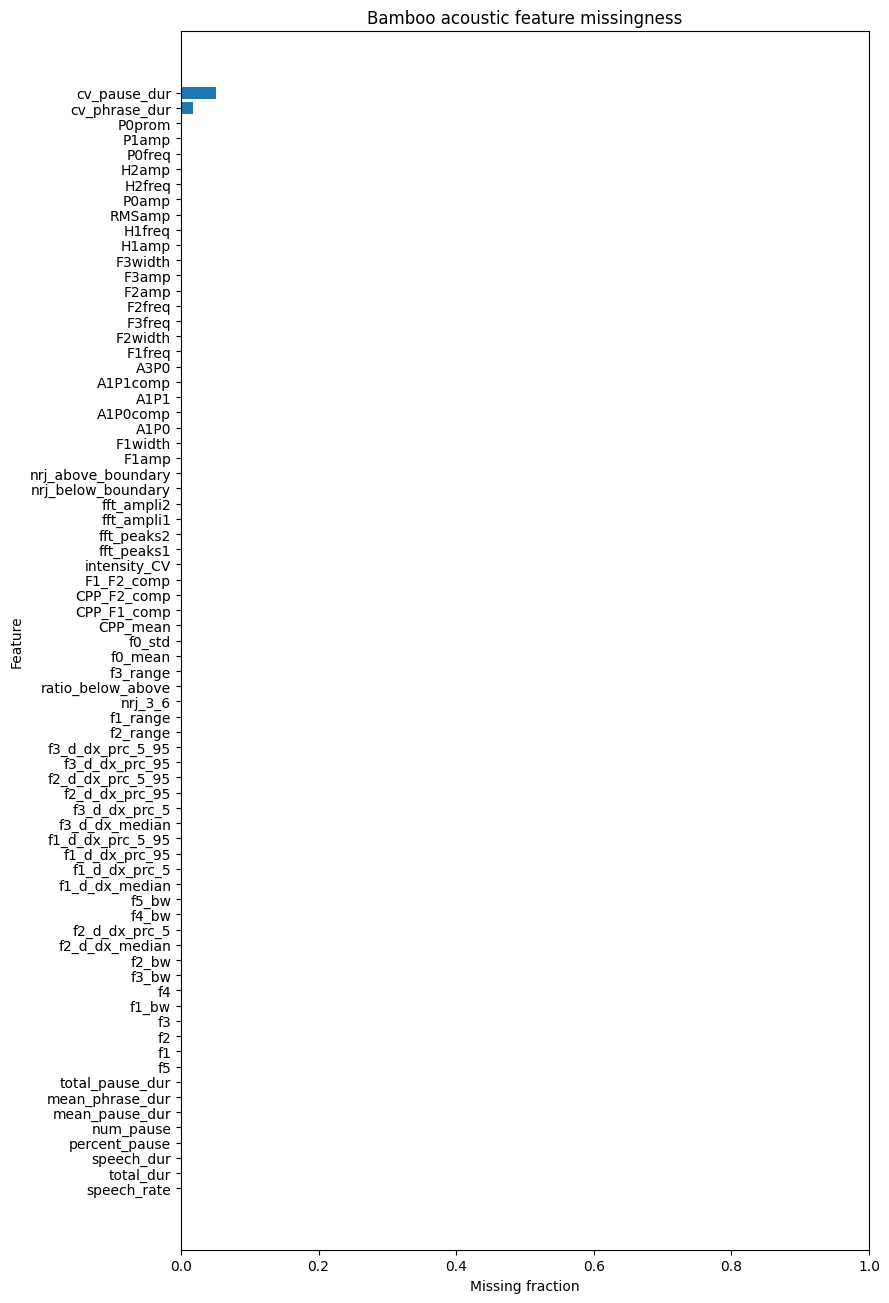

In [61]:
feature_audit_rows = []

for feature in ALL_FEATURE_NAMES:
    if feature not in acoustic_features_df.columns:
        feature_audit_rows.append({
            "feature": feature,
            "subsystem": FEATURE_REGISTRY.set_index("feature").loc[feature, "subsystem"],
            "missing_fraction": 1.0,
            "n_unique": 0,
            "variance": np.nan,
            "min": np.nan,
            "median": np.nan,
            "max": np.nan,
        })
        continue

    x = pd.to_numeric(acoustic_features_df[feature], errors="coerce")
    feature_audit_rows.append({
        "feature": feature,
        "subsystem": FEATURE_REGISTRY.set_index("feature").loc[feature, "subsystem"],
        "missing_fraction": float(x.isna().mean()),
        "n_unique": int(x.nunique(dropna=True)),
        "variance": safe_float(x.var(skipna=True)),
        "min": safe_float(x.min(skipna=True)),
        "median": safe_float(x.median(skipna=True)),
        "max": safe_float(x.max(skipna=True)),
    })

feature_audit_df = pd.DataFrame(feature_audit_rows)
FEATURE_AUDIT_FILE = TABLES_DIR / "bamboo_acoustic_feature_availability_audit.csv"
feature_audit_df.to_csv(FEATURE_AUDIT_FILE, index=False)

print("Feature audit saved:", FEATURE_AUDIT_FILE)

display(
    feature_audit_df
    .sort_values(["missing_fraction", "subsystem", "feature"])
    .head(30)
)

print("Subsystem-level missingness:")
display(
    feature_audit_df
    .groupby("subsystem")
    .agg(
        n_features=("feature", "count"),
        mean_missing_fraction=("missing_fraction", "mean"),
        median_missing_fraction=("missing_fraction", "median"),
        mean_n_unique=("n_unique", "mean"),
    )
    .sort_values("mean_missing_fraction")
)

if SAVE_PLOTS:
    plot_df = feature_audit_df.sort_values("missing_fraction", ascending=True)

    plt.figure(figsize=(9, max(5, 0.18 * len(plot_df))))
    plt.barh(plot_df["feature"], plot_df["missing_fraction"])
    plt.xlabel("Missing fraction")
    plt.ylabel("Feature")
    plt.title("Bamboo acoustic feature missingness")
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "acoustic_feature_missingness.png", dpi=300, bbox_inches="tight")
    plt.show()

## Cell 18 — Extraction diagnostics plots

These plots help you decide whether extraction succeeded before using the features for Study Goal 2. The most important checks are:

- mostly `ok` status;
- reasonable number of finite features per recording;
- no extreme extraction-time outliers;
- expected container mix.

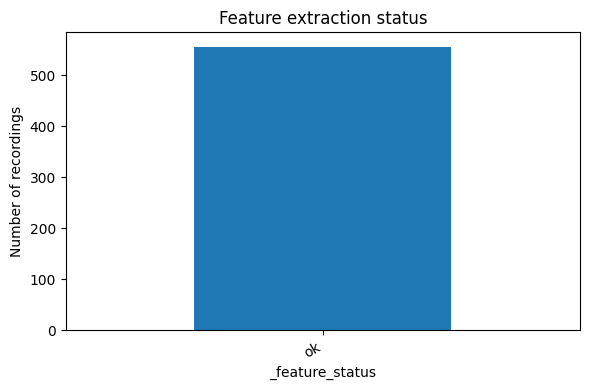

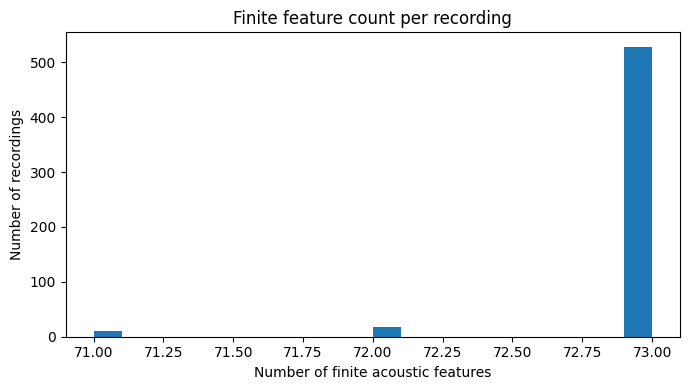

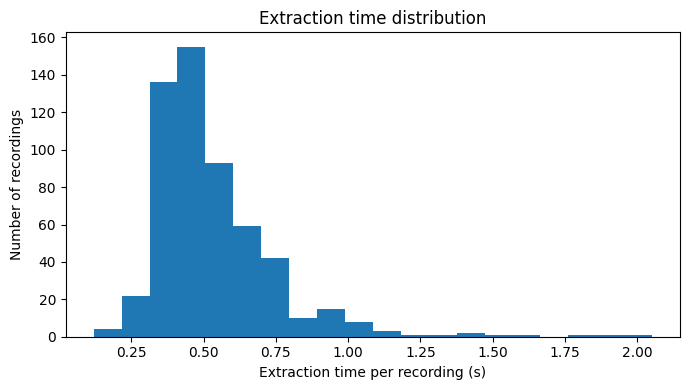

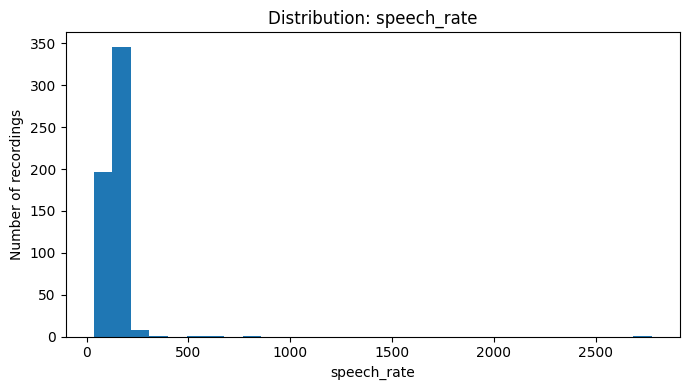

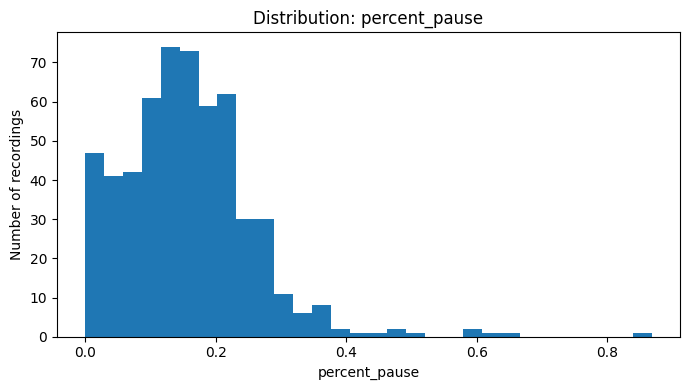

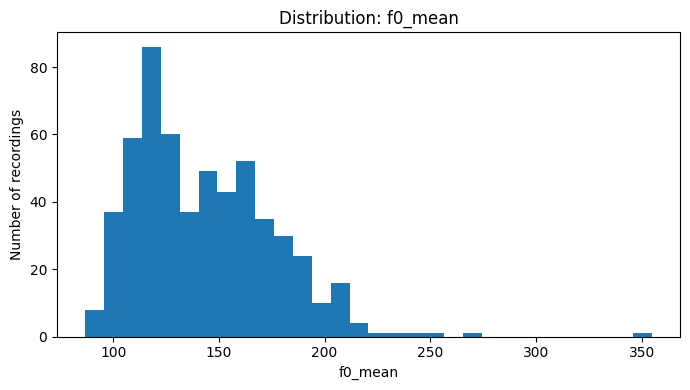

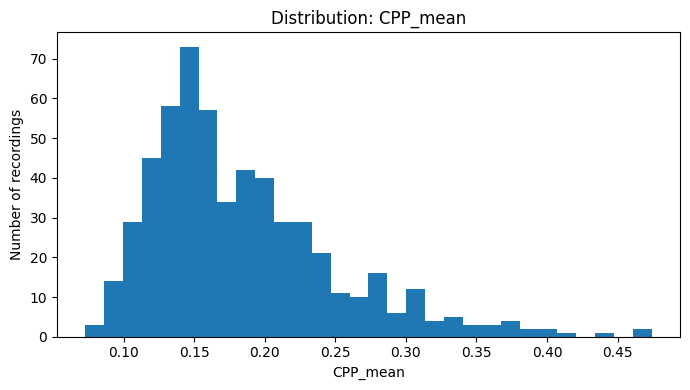

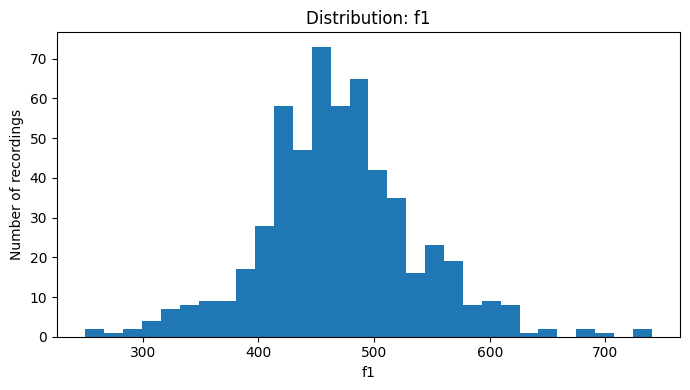

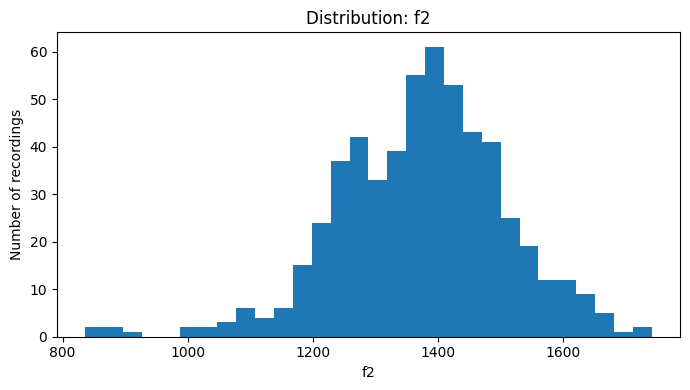

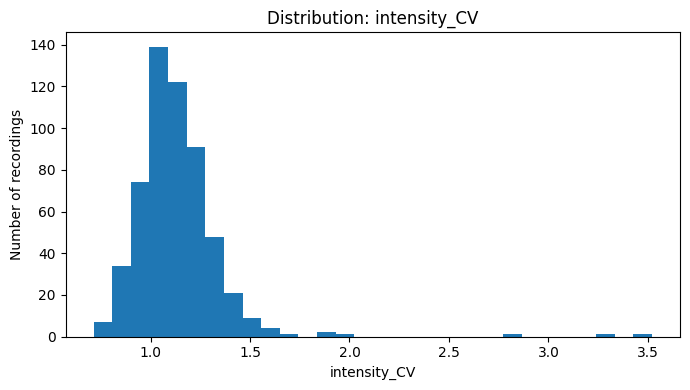

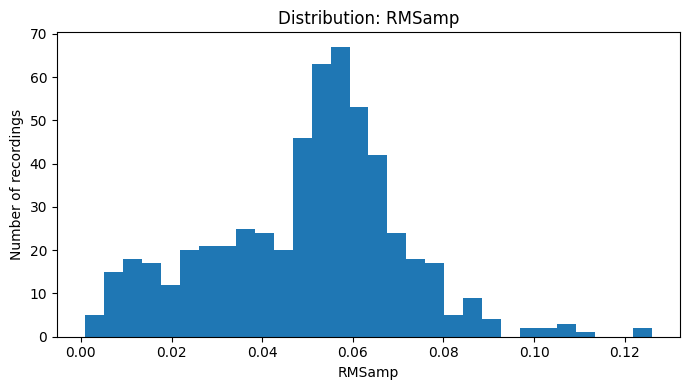

In [62]:
if SAVE_PLOTS:
    # Status count
    if "_feature_status" in acoustic_features_df.columns:
        plt.figure(figsize=(6, 4))
        acoustic_features_df["_feature_status"].value_counts(dropna=False).plot(kind="bar")
        plt.ylabel("Number of recordings")
        plt.title("Feature extraction status")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "feature_extraction_status_counts.png", dpi=300, bbox_inches="tight")
        plt.show()

    # Finite feature count
    if "_n_finite_features" in acoustic_features_df.columns:
        plt.figure(figsize=(7, 4))
        plt.hist(acoustic_features_df["_n_finite_features"].dropna(), bins=20)
        plt.xlabel("Number of finite acoustic features")
        plt.ylabel("Number of recordings")
        plt.title("Finite feature count per recording")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "finite_feature_count_histogram.png", dpi=300, bbox_inches="tight")
        plt.show()

    # Extraction seconds
    if "_extract_seconds" in acoustic_features_df.columns:
        plt.figure(figsize=(7, 4))
        plt.hist(acoustic_features_df["_extract_seconds"].dropna(), bins=20)
        plt.xlabel("Extraction time per recording (s)")
        plt.ylabel("Number of recordings")
        plt.title("Extraction time distribution")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "extraction_time_histogram.png", dpi=300, bbox_inches="tight")
        plt.show()

    # A few clinically interpretable feature distributions
    selected_features = [
        "speech_rate", "percent_pause", "f0_mean", "CPP_mean",
        "f1", "f2", "intensity_CV", "RMSamp"
    ]
    selected_features = [f for f in selected_features if f in acoustic_features_df.columns]

    for feature in selected_features:
        x = pd.to_numeric(acoustic_features_df[feature], errors="coerce")
        plt.figure(figsize=(7, 4))
        plt.hist(x.dropna(), bins=30)
        plt.xlabel(feature)
        plt.ylabel("Number of recordings")
        plt.title(f"Distribution: {feature}")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"distribution_{feature}.png", dpi=300, bbox_inches="tight")
        plt.show()

## Cell 19 — Optional diagnosis-stratified QC visualization

This cell does not perform inferential testing. It simply checks whether feature distributions look grossly different between ALS and controls. Formal modeling belongs in the Study Goal 2 notebook.

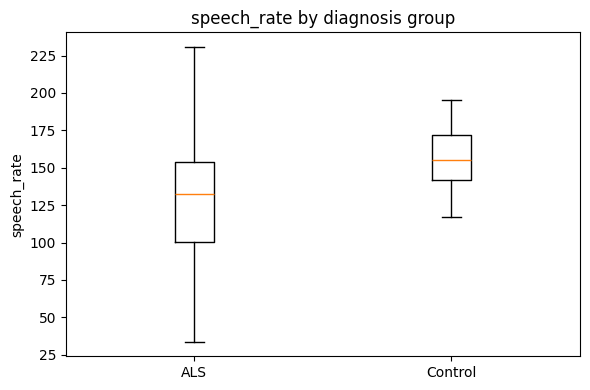

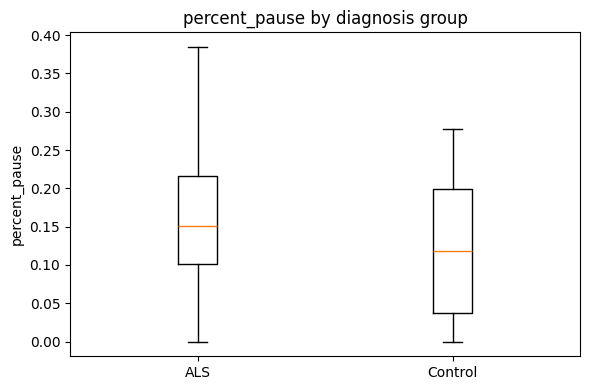

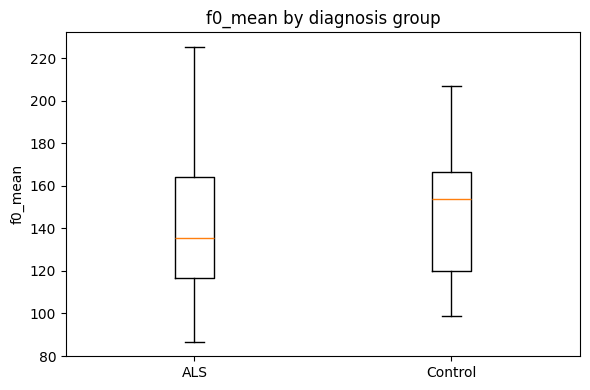

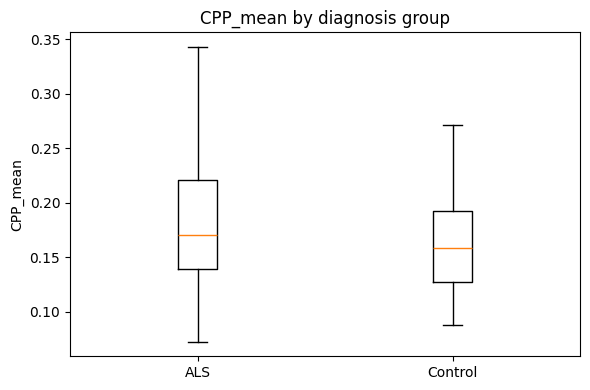

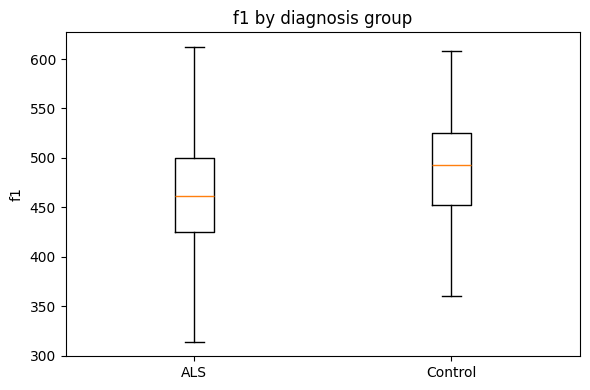

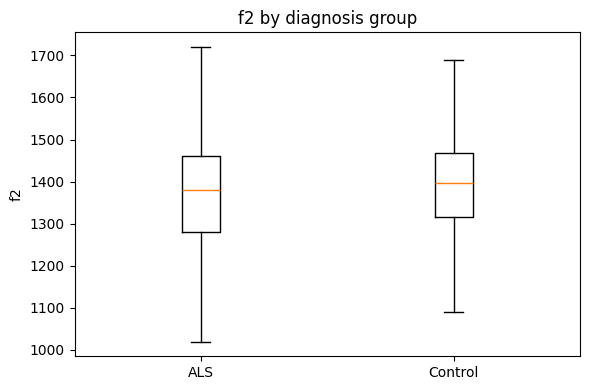

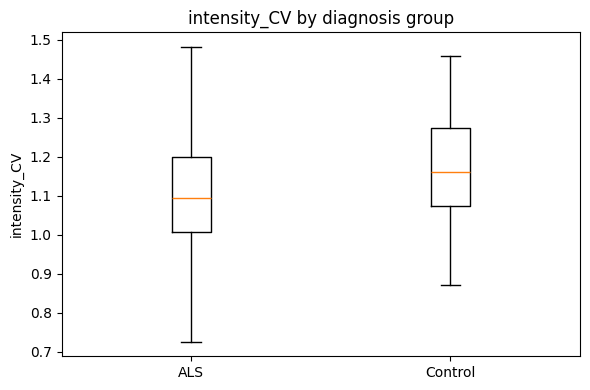

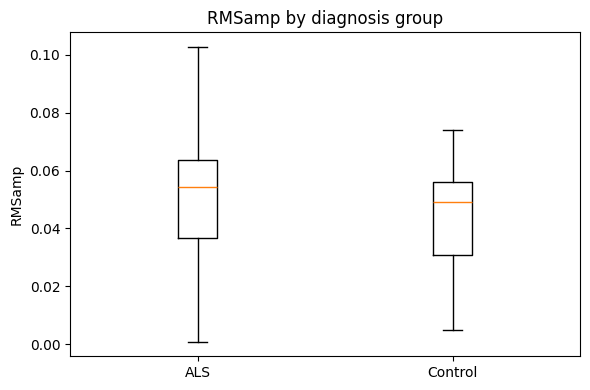

In [63]:
if SAVE_PLOTS and "diagnosis_group" in acoustic_features_df.columns:
    selected_features = [
        "speech_rate", "percent_pause", "f0_mean", "CPP_mean",
        "f1", "f2", "intensity_CV", "RMSamp"
    ]
    selected_features = [f for f in selected_features if f in acoustic_features_df.columns]

    for feature in selected_features:
        tmp = acoustic_features_df[["diagnosis_group", feature]].copy()
        tmp[feature] = pd.to_numeric(tmp[feature], errors="coerce")
        tmp = tmp.dropna()

        if tmp["diagnosis_group"].nunique() < 2 or len(tmp) < 5:
            continue

        groups = [g[feature].values for _, g in tmp.groupby("diagnosis_group")]

        plt.figure(figsize=(6, 4))
        plt.boxplot(groups, labels=[name for name, _ in tmp.groupby("diagnosis_group")], showfliers=False)
        plt.ylabel(feature)
        plt.title(f"{feature} by diagnosis group")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"boxplot_{feature}_by_diagnosis.png", dpi=300, bbox_inches="tight")
        plt.show()

## Cell 20 — Save final feature manifest

This final cell saves a compact manifest that tells the modeling notebook exactly where the feature file, registry, and audit tables are located.

In [64]:
manifest = {
    "timestamp": datetime.now().isoformat(),
    "extraction_mode": EXTRACTION_MODE,
    "n_rows_extracted": int(len(acoustic_features_df)),
    "feature_file": str(ACOUSTIC_FEATURE_FILE),
    "feature_registry_file": str(FEATURE_REGISTRY_FILE),
    "feature_audit_file": str(FEATURE_AUDIT_FILE),
    "audio_index_file": str(AUDIO_INDEX_FILE),
    "error_file": str(ACOUSTIC_ERROR_FILE),
    "target_sr": TARGET_SR,
    "bamboo_word_count": BAMBOO_WORD_COUNT,
    "n_registered_features": int(len(ALL_FEATURE_NAMES)),
    "n_ok": int((acoustic_features_df.get("_feature_status", pd.Series(dtype=str)) == "ok").sum()) if "_feature_status" in acoustic_features_df.columns else None,
}

MANIFEST_FILE = LOG_DIR / "bamboo_acoustic_feature_manifest.json"
with open(MANIFEST_FILE, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Manifest saved:", MANIFEST_FILE)
print(json.dumps(manifest, indent=2))

Manifest saved: C:\Users\musikicn\OneDrive - University of Toronto\! Paper 1 - Audio QC DL\Data\Bamboo_passage_English\paper2\results\acoustic_feature_extraction\logs\bamboo_acoustic_feature_manifest.json
{
  "timestamp": "2026-05-26T18:24:36.088044",
  "extraction_mode": "full",
  "n_rows_extracted": 556,
  "feature_file": "C:\\Users\\musikicn\\OneDrive - University of Toronto\\! Paper 1 - Audio QC DL\\Data\\Bamboo_passage_English\\paper2\\data\\interim\\acoustic_features\\bamboo_acoustic_features_recording_level.csv",
  "feature_registry_file": "C:\\Users\\musikicn\\OneDrive - University of Toronto\\! Paper 1 - Audio QC DL\\Data\\Bamboo_passage_English\\paper2\\results\\acoustic_feature_extraction\\tables\\bamboo_acoustic_feature_registry.csv",
  "feature_audit_file": "C:\\Users\\musikicn\\OneDrive - University of Toronto\\! Paper 1 - Audio QC DL\\Data\\Bamboo_passage_English\\paper2\\results\\acoustic_feature_extraction\\tables\\bamboo_acoustic_feature_availability_audit.csv",
  "au

In [65]:
print("Shape:", acoustic_features_df.shape)

display(
    acoustic_features_df["_feature_status"]
    .value_counts(dropna=False)
    .rename("n")
    .to_frame()
)

display(
    acoustic_features_df["_n_finite_features"]
    .describe()
    .to_frame("n_finite_features")
)

display(
    acoustic_features_df["_extract_seconds"]
    .describe()
    .to_frame("extract_seconds")
)

Shape: (556, 92)


,n
_feature_status,
ok,556


,n_finite_features
count,556.000000
mean,72.931655
std,0.315951
min,71.000000
25%,73.000000
50%,73.000000
75%,73.000000
max,73.000000


,extract_seconds
count,556.000000
mean,0.532235
std,0.220158
min,0.119497
25%,0.397598
50%,0.475907
75%,0.609756
max,2.052208


In [66]:
feature_cols = ALL_FEATURE_NAMES

batch_missingness = (
    acoustic_features_df[feature_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .to_frame()
)

display(batch_missingness.head(40))
display(batch_missingness.tail(40))

,missing_fraction
cv_pause_dur,0.050360
cv_phrase_dur,0.017986
speech_rate,0.000000
total_dur,0.000000
speech_dur,0.000000
num_pause,0.000000
percent_pause,0.000000
mean_phrase_dur,0.000000
mean_pause_dur,0.000000
total_pause_dur,0.000000


,missing_fraction
f2_range,0.0
f3_range,0.0
f0_mean,0.0
f0_std,0.0
CPP_mean,0.0
CPP_F1_comp,0.0
CPP_F2_comp,0.0
F1_F2_comp,0.0
intensity_CV,0.0
fft_peaks1,0.0
